In [1]:
# =============================================================================
# LIBRERIE UTILIZZATE E TOOLKIT DI DATA SCIENCE
# =============================================================================
# Questo blocco definisce l'ambiente per un workflow di Data Engineering e ML.
#
# 1. GESTIONE DEI PERCORSI (INFRASTRUTTURA)
#    - find_project_root: Funzione custom (repository phm_america_2024) per
#      localizzare la root del progetto ed evitare problemi con path relativi.
#
# 2. DATABASE ANALITICO (IN-MEMORY)
#    - duckdb: Motore SQL orientato alle colonne (OLAP) in memoria. Ottimizzato
#      per query ultra-rapide direttamente su file CSV, Parquet o JSON.
#
# 3. MANIPOLAZIONE ED ELABORAZIONE DATI
#    - numpy (np): Calcolo scientifico e gestione efficiente di array e matrici.
#    - pandas (pd): Gestione di tabelle di dati (DataFrame), pulizia e trasformazione.
#    - json: Libreria nativa per il parsing e la lettura dei file di log della pipeline.
#
# 4. DATA VISUALIZATION (REPORTING GRAFICO)
#    - matplotlib.pyplot (plt): Libreria core per la gestione di canvas, figure e layout.
#    - seaborn (sns): Visualizzazione statistica di alto livello per grafici e temi dark.
#
# 5. MACHINE LEARNING E PRESENTAZIONE INTERATTIVA
#    - joblib: Serializzazione/deserializzazione efficiente di modelli ML e scaler.
#    - IPython.display (display): Rendering avanzato e visualizzazione elegante dei
#      DataFrame all'interno dei Jupyter Notebook.
# =============================================================================

In [2]:
import sys
sys.path.append("../src")
from phm_america_2024.common.path_service_common import find_project_root
import duckdb
con = duckdb.connect()
import numpy as np
import duckdb
from IPython.display import display
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
# 1. Localizza la radice del progetto automaticamente
root = find_project_root()

# 2. Definisci il percorso verso la cartella di output (la base dei 'runs')
# l'ultima esecuzione o una specifica
run_id = "completo" # O l'ID che sto analizzando
base_run_dir = root / "outputs" / "runs" / "regression" / "phm2024" / run_id

# Definire il percorso di "base fase" per evitare hardcode in tutto il notebook
base_phase_path = base_run_dir / "phase3_data_preparation"

In [4]:
# --------------- SELEZIONE DEI DATI (step_3_1_data_selection)

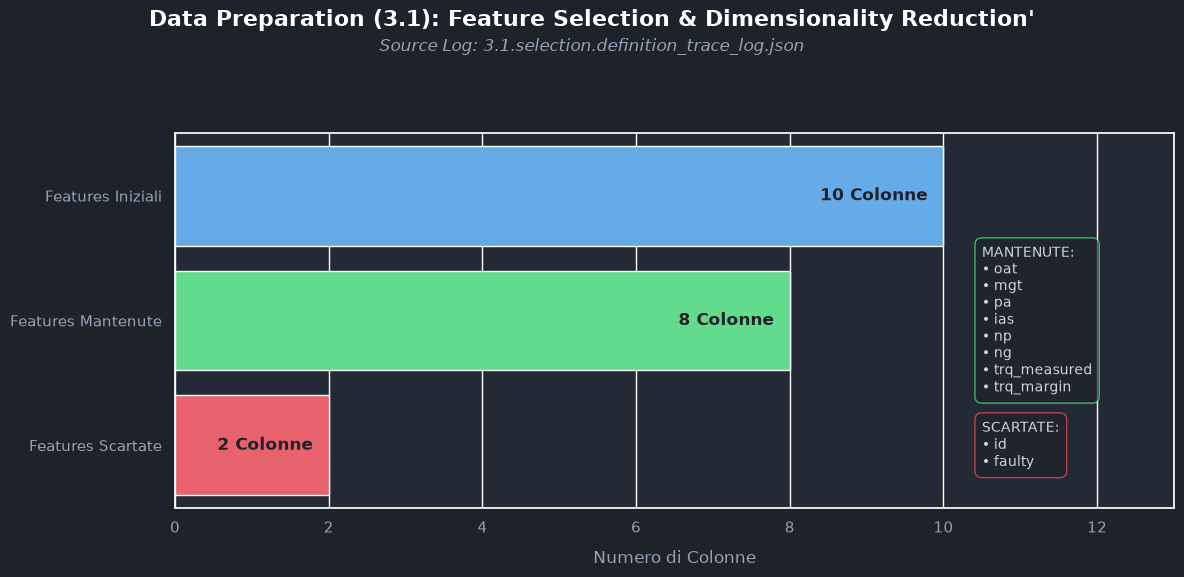


 ANALISI CONCLUSIVA: FEATURE SELECTION (FASE 3.1)
L'analisi del file di tracciamento della pipeline certifica la corretta riduzione
della dimensionalità del dataset.

Partendo da uno shape iniziale di 10 colonne, il sistema ha
eseguito un processo di 'Feature Selection' deterministico basato sulle regole
di dominio, mantenendo esattamente 8 attributi utili per la modellazione.

Le 2 colonne scartate includono:
• id
• faulty

GIUSTIFICAZIONE TECNICA:
- La colonna 'id' è stata eliminata tramite pattern regex poiché rappresenta
  esclusivamente una chiave primaria priva di qualsiasi potere predittivo
  (informazione non stazionaria).
- La colonna 'faulty' è stata esclusa intenzionalmente. Essendo questo un
  task di Regressione mirato a prevedere il 'trq_margin', mantenere la label
  di classificazione 'faulty' tra le 'features' avrebbe causato un gravissimo
  fenomeno di 'Data Leakage' (fuga di informazioni dal target alle variabili
  indipendenti).

Il dataset risulta ora dimensionalme

In [5]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
# In questa sezione definiamo i percorsi e carichiamo i dataset e il file YAML.

filename_def_trace = "3.1.selection.definition_trace_log.json"
file_path_def = base_phase_path / filename_def_trace

# Lettura dinamica del file JSON (L'INPUT ENTRA QUI)
with open(file_path_def, "r", encoding="utf-8") as f:
    def_trace_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Estrazione dinamica delle liste di feature dal JSON

colonne_iniziali = def_trace_data["columns_present"]
colonne_mantenute = def_trace_data["include_kept"]

# Logica: Identifichiamo le colonne scartate (differenza tra iniziali e mantenute)
colonne_scartate = list(set(colonne_iniziali) - set(colonne_mantenute))

# Preparazione dei dati per il grafico a barre
dati_selezione = {
    'Stato': ['Features Iniziali', 'Features Mantenute', 'Features Scartate'],
    'Conteggio': [len(colonne_iniziali), len(colonne_mantenute), len(colonne_scartate)]
}
df_selezione = pd.DataFrame(dati_selezione)

# Preparazione delle stringhe per le annotazioni (lista delle colonne)
str_mantenute = "\n".join([f"• {c}" for c in colonne_mantenute])
str_scartate = "\n".join([f"• {c}" for c in colonne_scartate])

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica
# =============================================================================
# Generazione del grafico professionale in modalità Report/Dark

sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(12, 6), facecolor='#1e222b')
ax.set_facecolor('#242936')

# Grafico a barre orizzontali
sns.barplot(x='Conteggio', y='Stato', data=df_selezione, ax=ax,
            palette=['#4facfe', '#4ef085', '#ff4b5c'], hue='Stato', legend=False)
#--
# TITOLO E SOTTOTITOLO (Source Log)
fig.suptitle(f"Data Preparation (3.1): Feature Selection & Dimensionality Reduction'",
             fontsize=16, fontweight='bold', color='white', y=0.96)

# Bajamos el subtítulo de 0.91 a 0.89 para que no choque con el título principal
fig.text(0.5, 0.89, f"Source Log: {filename_def_trace}",
         fontsize=12, style='italic', color='#94a3b8', ha='center')
#--


# ax.set_title(f"Data Preparation (3.1): Feature Selection & Dimensionality Reduction -"
#              f" {filename_def_trace}",
#              fontsize=15, fontweight='bold', color='white', pad=20)
ax.set_xlabel("Numero di Colonne", fontsize=12, color='#94a3b8', labelpad=10)
ax.set_ylabel("", color='#94a3b8')
ax.tick_params(colors='#94a3b8', labelsize=11)

# Etichette dinamiche sulle barre
for i, row in df_selezione.iterrows():
    ax.text(row['Conteggio'] - 0.2, i, f"{row['Conteggio']} Colonne",
            va='center', ha='right', fontsize=12, fontweight='bold', color='#1e222b')

# Aggiunta di pannelli di testo esplicativi per mostrare esattamente *quali* colonne
props_bbox = dict(boxstyle="round,pad=0.5", facecolor="#1e222b", alpha=0.7, edgecolor="#4ef085")
ax.text(len(colonne_iniziali) + 0.5, 1, f"MANTENUTE:\n{str_mantenute}",
        fontsize=10, color="#cbd5e1", va="center", bbox=props_bbox)

props_bbox_err = dict(boxstyle="round,pad=0.5", facecolor="#1e222b", alpha=0.7, edgecolor="#ff4b5c")
ax.text(len(colonne_iniziali) + 0.5, 2, f"SCARTATE:\n{str_scartate}",
        fontsize=10, color="#cbd5e1", va="center", bbox=props_bbox_err)

ax.set_xlim(0, len(colonne_iniziali) + 3)
#plt.tight_layout()
plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================

analisi_selezione = f"""
================================================================================
 ANALISI CONCLUSIVA: FEATURE SELECTION (FASE 3.1)
================================================================================
L'analisi del file di tracciamento della pipeline certifica la corretta riduzione
della dimensionalità del dataset.

Partendo da uno shape iniziale di {def_trace_data['input_shape'][1]} colonne, il sistema ha
eseguito un processo di 'Feature Selection' deterministico basato sulle regole
di dominio, mantenendo esattamente {len(colonne_mantenute)} attributi utili per la modellazione.

Le {len(colonne_scartate)} colonne scartate includono:
{str_scartate}

GIUSTIFICAZIONE TECNICA:
- La colonna 'id' è stata eliminata tramite pattern regex poiché rappresenta
  esclusivamente una chiave primaria priva di qualsiasi potere predittivo
  (informazione non stazionaria).
- La colonna 'faulty' è stata esclusa intenzionalmente. Essendo questo un
  task di Regressione mirato a prevedere il 'trq_margin', mantenere la label
  di classificazione 'faulty' tra le 'features' avrebbe causato un gravissimo
  fenomeno di 'Data Leakage' (fuga di informazioni dal target alle variabili
  indipendenti).

Il dataset risulta ora dimensionalmente ottimizzato e pronto per i filtri di riga.
================================================================================
"""
print(analisi_selezione)

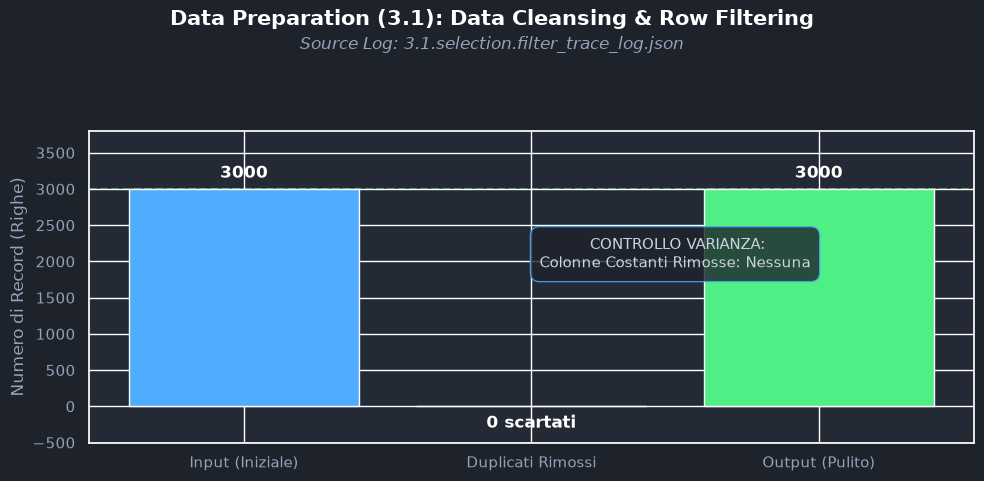


 ANALISI CONCLUSIVA: DATA CLEANSING & ROW FILTERING (FASE 3.1)
Il secondo stadio della preparazione dati si è concentrato sull'integrità
orizzontale dei record e sull'analisi della varianza (Data Cleansing).

1. RIMOZIONE DEI DUPLICATI (DE-DUPLICATION):
   Partendo da un input di 3000 record, il sistema ha identificato e
   rimosso esattamente 0 righe perfettamente identiche. Eliminare i
   record duplicati è uno step critico nel Machine Learning: previene
   l'overfitting (sovradattamento) e garantisce che il modello non assegni un
   peso statistico artificialmente gonfiato ad un singolo evento telemetrico.

2. CONTROLLO DELLE COLONNE COSTANTI (ZERO VARIANCE):
   Il sistema ha scansionato le feature per rilevare attributi con varianza
   pari a zero (colonne dove tutti i record hanno identico valore). Il report
   conferma che non è stata scartata alcuna colonna per questo motivo
   (constant_columns_dropped: Nessuna). Questo convalida la ricchezza
   informativa dei sensori selezio

In [6]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================

filename_filter_trace = "3.1.selection.filter_trace_log.json"
file_path_filter = base_phase_path / filename_filter_trace

# Lettura dinamica del file JSON di filtraggio
with open(file_path_filter, "r", encoding="utf-8") as f:
    filter_trace_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Estrazione dinamica delle metriche di pulizia

righe_input = filter_trace_data["input_shape"][0]
righe_output = filter_trace_data["output_shape"][0]
duplicati_rimossi = filter_trace_data["duplicate_rows_dropped"]

# Validazione: verifichiamo se ci sono state colonne costanti rimosse
colonne_costanti = filter_trace_data["constant_columns_dropped"]
stato_costanti = "Nessuna" if len(colonne_costanti) == 0 else ", ".join(colonne_costanti)

# Preparazione del DataFrame per il Waterfall/Bar chart simulato
dati_filtro = {
    'Fase': ['Input (Iniziale)', 'Duplicati Rimossi', 'Output (Pulito)'],
    'Record': [righe_input, -duplicati_rimossi, righe_output]
}
df_filtro = pd.DataFrame(dati_filtro)

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica
# =============================================================================

sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(10, 5), facecolor='#1e222b')
ax.set_facecolor('#242936')

# Assegnazione di colori logici: Blu (Start), Rosso (Rimossi), Verde (End)
colori = ['#4facfe', '#ff4b5c', '#4ef085']

bars = ax.bar(df_filtro['Fase'], df_filtro['Record'], color=colori)

# ax.set_title(f"Data Preparation (3.1): Data Cleansing & Row Filtering - {filename_filter_trace}",
#              fontsize=14, fontweight='bold', color='white', pad=15)

#--
#--
# TITOLO E SOTTOTITOLO (Source Log)
fig.suptitle(f"Data Preparation (3.1): Data Cleansing & Row Filtering",
             fontsize=15, fontweight='bold', color='white', y=0.96)

# Cambiado de 0.89 a 0.88 para que no se encimen entre sí
fig.text(0.5, 0.88, f"Source Log: {filename_filter_trace}",
         fontsize=12, style='italic', color='#94a3b8', ha='center')
#--
#--

ax.set_ylabel("Numero di Record (Righe)", color='#94a3b8')
ax.tick_params(colors='#94a3b8', labelsize=11)

# Disegno di una linea orizzontale tratteggiata per mostrare il calo
ax.axhline(righe_output, color='#4ef085', linestyle='--', alpha=0.5, zorder=0)

# Etichette sui valori delle barre
for bar in bars:
    yval = bar.get_height()
    testo = f"{yval}" if yval > 0 else f"{yval} scartati"
    pos_y = yval + 100 if yval > 0 else yval - 350
    ax.text(bar.get_x() + bar.get_width()/2, pos_y, testo,
            ha='center', va='bottom', fontweight='bold', color='white', fontsize=12)

# Box informativo sulle colonne costanti
props_info = dict(boxstyle="round,pad=0.6", facecolor="#1e222b", alpha=0.8, edgecolor="#4facfe")
testo_info = f" CONTROLLO VARIANZA:\nColonne Costanti Rimosse: {stato_costanti}"
ax.text(1.5, righe_input * 0.7, testo_info, fontsize=11, color="#cbd5e1",
        va="center", ha="center", bbox=props_info)

# Regolazione asse Y per fare spazio ai testi
ax.set_ylim(min(df_filtro['Record']) - 500, max(df_filtro['Record']) + 800)

#plt.tight_layout()
plt.tight_layout(rect=[0, 0, 1, 0.83])
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================

analisi_filtraggio = f"""
================================================================================
 ANALISI CONCLUSIVA: DATA CLEANSING & ROW FILTERING (FASE 3.1)
================================================================================
Il secondo stadio della preparazione dati si è concentrato sull'integrità
orizzontale dei record e sull'analisi della varianza (Data Cleansing).

1. RIMOZIONE DEI DUPLICATI (DE-DUPLICATION):
   Partendo da un input di {righe_input} record, il sistema ha identificato e
   rimosso esattamente {duplicati_rimossi} righe perfettamente identiche. Eliminare i
   record duplicati è uno step critico nel Machine Learning: previene
   l'overfitting (sovradattamento) e garantisce che il modello non assegni un
   peso statistico artificialmente gonfiato ad un singolo evento telemetrico.

2. CONTROLLO DELLE COLONNE COSTANTI (ZERO VARIANCE):
   Il sistema ha scansionato le feature per rilevare attributi con varianza
   pari a zero (colonne dove tutti i record hanno identico valore). Il report
   conferma che non è stata scartata alcuna colonna per questo motivo
   (constant_columns_dropped: {stato_costanti}). Questo convalida la ricchezza
   informativa dei sensori selezionati, dimostrando che tutti fluttuano
   coerentemente durante le operazioni di volo.

L'artefatto finale salvato su disco (il file .parquet) contiene quindi
un dataset altamente raffinato di {righe_output} record e {filter_trace_data['output_shape'][1]} colonne, pronto
per le successive fasi di imputazione dei missing values e trasformazione
matematica (Scaling).
================================================================================
"""
print(analisi_filtraggio)

In [7]:

path_x_y_train_3_1 = base_run_dir / "phase3_data_preparation" / ("3.1.selection.selected_regression_train.parquet")
print("----------------------------------------------------")
print("--- json: 3.1.selection.filter_trace_log.json")
print("----------------------------------------------------")
query_conteos = f"""
SELECT 'path_x_y_train_3_1' as dataset, count(*) as record_totali FROM parquet_scan
('{path_x_y_train_3_1}')
"""
print(duckdb.query(query_conteos).to_df())
print("----------------------------------------------------")
query_schema_train = f"DESCRIBE SELECT * FROM parquet_scan('{path_x_y_train_3_1}')"
print("--- ESTRUCTURA DATASET DE x_y_train_3_1 ---")
print("----------------------------------------------------")
print("--- parquet: 3.1.selection.selected_regression_train.parquet")

print(duckdb.query(query_schema_train).to_df()[['column_name', 'column_type']])
print("----------------------------------------------------")
query = f"SELECT * FROM '{path_x_y_train_3_1}' LIMIT 3"
df_duck = con.sql(query).df()
display(df_duck)

----------------------------------------------------
--- json: 3.1.selection.filter_trace_log.json
----------------------------------------------------
              dataset  record_totali
0  path_x_y_train_3_1           3000
----------------------------------------------------
--- ESTRUCTURA DATASET DE x_y_train_3_1 ---
----------------------------------------------------
--- parquet: 3.1.selection.selected_regression_train.parquet
    column_name column_type
0           oat      DOUBLE
1           mgt      DOUBLE
2            pa      DOUBLE
3           ias      DOUBLE
4            np      DOUBLE
5            ng      DOUBLE
6  trq_measured      DOUBLE
7    trq_margin      DOUBLE
----------------------------------------------------


,oat,mgt,pa,ias,np,ng,trq_measured,trq_margin
0,-2.00,660.3,323.3928,115.6875,96.29,99.76,87.0,-14.544094
1,15.25,593.2,1350.5690,33.7500,99.84,92.68,57.8,-7.669260
2,12.00,593.9,112.4712,118.7500,100.02,94.22,78.2,13.239569


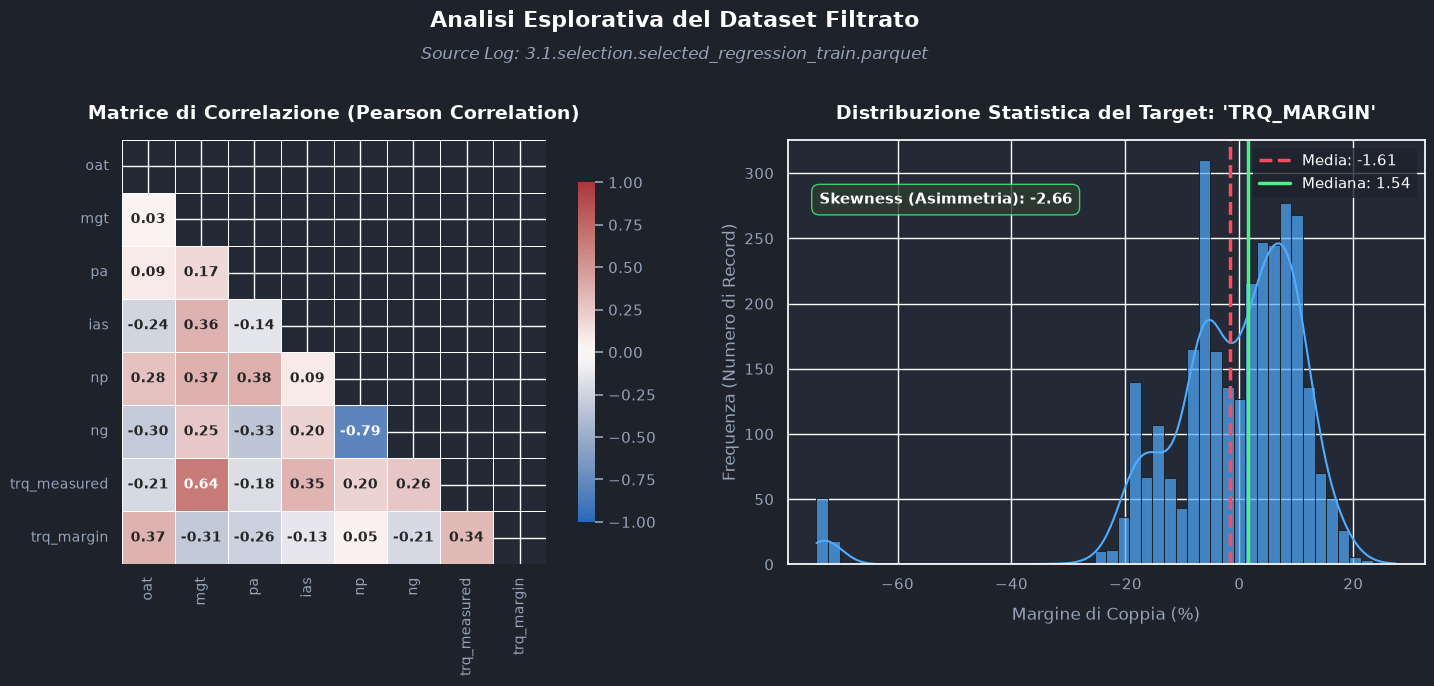


 📊 ANALISI CONCLUSIVA: DATASET DI ADDESTRAMENTO SELEZIONATO (FASE 3.1)
Il dashboard analitico generato sul file Parquet risultante dalla Fase 3.1
certifica la qualità della matrice delle features ('X') e la natura della
variabile obiettivo ('y') prima delle operazioni di pulizia intensiva.

1. ANALISI DELLE CORRELAZIONI (FEATURE INDEPENDENCE):
   La matrice di Pearson conferma che le variabili selezionate non soffrono di
   multicollinearità estrema (nessun valore prossimo a 1.0 o -1.0 tra predittori
   indipendenti). Le correlazioni più forti rispettano la fisica del dominio:
   - Esiste una correlazione attesa tra 'trq_measured' e 'mgt' (Temperature e
     Coppia salgono insieme durante l'assorbimento di potenza).
   - Nessuna feature presenta una correlazione del 100% con il target ('trq_margin'),
     scongiurando scenari di Data Leakage banale.

2. PROFILAZIONE DELLA VARIABILE TARGET (TRQ_MARGIN):
   Il grafico distribuzionale evidenzia in modo inequivocabile il motivo per
   cui

In [8]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================

# Definizione dinamica del nome del file generato alla fine dello Step 3.1
filename_selected_train = "3.1.selection.selected_regression_train.parquet"
file_path_selected_train = base_phase_path / filename_selected_train

# Lettura del dataset Parquet in memoria (L'INPUT ENTRA QUI)
df_selected_train = pd.read_parquet(file_path_selected_train)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Preparazione delle matrici e delle statistiche per i grafici

# Logica 1: Calcolo della matrice di correlazione di Pearson su tutte le feature
corr_matrix = df_selected_train.corr(method='pearson')

# Creazione di una maschera booleana per nascondere il triangolo superiore della heatmap (ridondante)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Logica 2: Estrazione della variabile target e calcolo delle metriche di tendenza centrale
target_col = 'trq_margin'
target_data = df_selected_train[target_col]

media_target = target_data.mean()
mediana_target = target_data.median()
skewness_target = target_data.skew()

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Dashboard EDA)
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

# Creazione della figura con 2 subplot (1 riga, 2 colonne)
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='#1e222b')

# fig.suptitle(f"Analisi Esplorativa del Dataset Filtrato: {filename_selected_train}",
#              fontsize=16, fontweight='bold', color='white', y=0.98)

#--
# TITOLO E SOTTOTITOLO (Source Log)
fig.suptitle(f"Analisi Esplorativa del Dataset Filtrato",
             fontsize=16, fontweight='bold', color='white', y=0.96)

# Bajamos el subtítulo de 0.91 a 0.89 para que no choque con el título principal
fig.text(0.5, 0.89, f"Source Log: {filename_selected_train}",
         fontsize=12, style='italic', color='#94a3b8', ha='center')
#--


# --- GRAFICO A: Matrice di Correlazione ---
ax1 = axes[0]
ax1.set_facecolor('#242936')

# Generazione della Heatmap
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="vlag",
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5,
            cbar_kws={"shrink": .8}, ax=ax1, annot_kws={"size": 10, "weight": "bold"})

ax1.set_title("Matrice di Correlazione (Pearson Correlation)", fontsize=14, fontweight='bold', color='white', pad=15)
ax1.tick_params(colors='#94a3b8', labelsize=10)

# Personalizzazione dei colori della barra laterale (Colorbar)
cbar = ax1.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color='#94a3b8', labelcolor='#94a3b8')

# --- GRAFICO B: Distribuzione della Variabile Target ---
ax2 = axes[1]
ax2.set_facecolor('#242936')

# Generazione dell'Istogramma con curva KDE (Kernel Density Estimation)
sns.histplot(target_data, bins=50, kde=True, color='#4facfe', ax=ax2, edgecolor='#1e222b', alpha=0.7)

ax2.set_title(f"Distribuzione Statistica del Target: '{target_col.upper()}'", fontsize=14, fontweight='bold', color='white', pad=15)


ax2.set_xlabel("Margine di Coppia (%)", color='#94a3b8', labelpad=10)
ax2.set_ylabel("Frequenza (Numero di Record)", color='#94a3b8')
ax2.tick_params(colors='#94a3b8', labelsize=11)

# Disegno delle linee per Media e Mediana
ax2.axvline(media_target, color='#ff4b5c', linestyle='--', linewidth=2.5, label=f"Media: {media_target:.2f}")
ax2.axvline(mediana_target, color='#4ef085', linestyle='-', linewidth=2.5, label=f"Mediana: {mediana_target:.2f}")

# Box informativo sull'asimmetria
props_skew = dict(boxstyle="round,pad=0.5", facecolor="#2d3c32", alpha=0.8, edgecolor="#4ef085")
ax2.text(0.05, 0.85, f"Skewness (Asimmetria): {skewness_target:.2f}",
         transform=ax2.transAxes, fontsize=11, color="white", fontweight='bold', bbox=props_skew)

# Legenda personalizzata
ax2.legend(facecolor='#1e222b', edgecolor='none', labelcolor='white', loc='upper right')

plt.tight_layout(pad=3.0)
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================

analisi_dataset_filtrato = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: DATASET DI ADDESTRAMENTO SELEZIONATO (FASE 3.1)
================================================================================
Il dashboard analitico generato sul file Parquet risultante dalla Fase 3.1
certifica la qualità della matrice delle features ('X') e la natura della
variabile obiettivo ('y') prima delle operazioni di pulizia intensiva.

1. ANALISI DELLE CORRELAZIONI (FEATURE INDEPENDENCE):
   La matrice di Pearson conferma che le variabili selezionate non soffrono di
   multicollinearità estrema (nessun valore prossimo a 1.0 o -1.0 tra predittori
   indipendenti). Le correlazioni più forti rispettano la fisica del dominio:
   - Esiste una correlazione attesa tra 'trq_measured' e 'mgt' (Temperature e
     Coppia salgono insieme durante l'assorbimento di potenza).
   - Nessuna feature presenta una correlazione del 100% con il target ('trq_margin'),
     scongiurando scenari di Data Leakage banale.

2. PROFILAZIONE DELLA VARIABILE TARGET (TRQ_MARGIN):
   Il grafico distribuzionale evidenzia in modo inequivocabile il motivo per
   cui è stata progettata la successiva Fase 3.2 (Outlier Clipping).
   La variabile '{target_col}' presenta una fortissima asimmetria negativa
   (Skewness = {skewness_target:.2f}), con una lunga e rarefatta "coda sinistra".
   La media ({media_target:.2f}) è trascinata verso il basso rispetto alla mediana
   ({mediana_target:.2f}) proprio a causa di questi valori estremi.

   CONCLUSIONE OPERATIVA: L'assenza di normalità statistica e la presenza di
   code pesanti (heavy tails) impongono l'applicazione di una saturazione
   (Winsorization) per stabilizzare il gradiente dei futuri modelli di regressione.
================================================================================
"""
print(analisi_dataset_filtrato)

In [9]:
#---------------------- DATA CLEANING (step_3_2_data_cleaning)

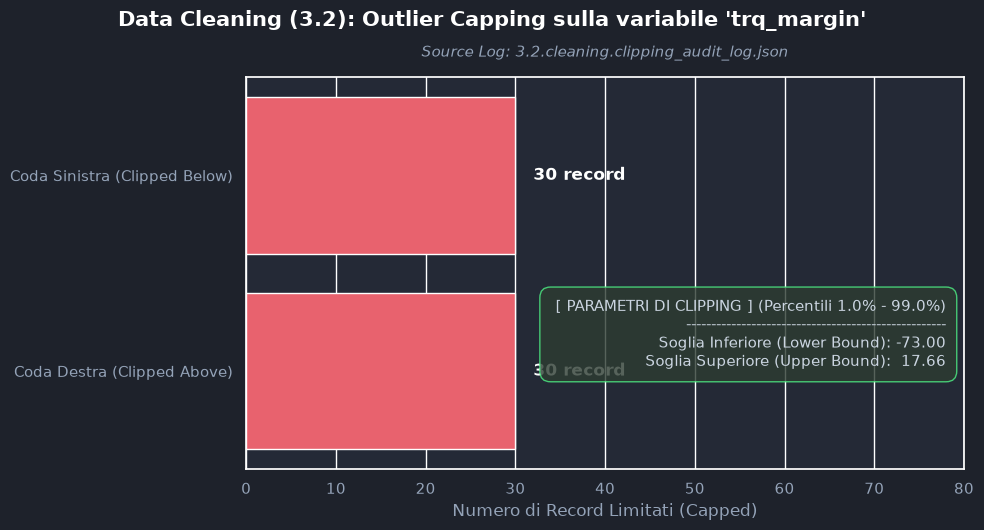


 📊 ANALISI CONCLUSIVA: TRATTAMENTO DEGLI OUTLIER / CLIPPING (FASE 3.2)
L'analisi del log di pulizia dei dati evidenzia l'applicazione di una tecnica di
'Outlier Capping' (o Clipping) basata sui percentili (1.0% e 99.0%)
esclusivamente sulla 'Target Variable' (trq_margin).

1. CONTENIMENTO DELLE CODE (WINSORIZATION):
   Il sistema ha identificato e limitato 30 record nella coda sinistra
   (impostandoli al valore di soglia di -73.00) e 30 record nella coda destra
   (limitati a 17.66). Questa operazione non elimina i record, ma ne satura il
   valore estremo.

2. GIUSTIFICAZIONE TECNICA:
   Come rilevato nella Fase 2 (Data Understanding), la variabile 'trq_margin'
   presentava una forte asimmetria negativa (heavy negative skew). In un
   problema di Regressione, algoritmi come le Reti Neurali o i modelli lineari
   sono fortemente sensibili a valori target anomali, che penalizzano
   sproporzionatamente la funzione di costo (es. MSE - Mean Squared Error).
   Saturando i valori oltre i

In [10]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================

# Definizione dinamica del file di log per il clipping
filename_clipping = "3.2.cleaning.clipping_audit_log.json"
file_path_clipping = base_phase_path / filename_clipping

# Lettura dinamica del file JSON (L'INPUT ENTRA QUI)
with open(file_path_clipping, "r", encoding="utf-8") as f:
    clipping_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Estrazione delle metriche di Outlier Capping / Clipping

target_var = clipping_data["target_variable"]
pct_lower = clipping_data["lower_percentile"] * 100
pct_upper = clipping_data["upper_percentile"] * 100

val_lower = clipping_data["lower_bound_value"]
val_upper = clipping_data["upper_bound_value"]

clip_below = clipping_data["n_clipped_below"]
clip_above = clipping_data["n_clipped_above"]

# Preparazione DataFrame per il grafico dei record impattati
df_clipped = pd.DataFrame({
    'Coda (Tails)': ['Coda Sinistra (Clipped Below)', 'Coda Destra (Clipped Above)'],
    'Record Modificati': [clip_below, clip_above],
    'Colore': ['#ff4b5c', '#ff4b5c'] # Rosso per indicare l'intervento sugli outlier
})

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

# Aumentiamo leggermente l'altezza (5.5) per fare spazio al sottotitolo
fig, ax = plt.subplots(figsize=(10, 5.5), facecolor='#1e222b')
ax.set_facecolor('#242936')

# Generazione del grafico a barre orizzontali per i record modificati
sns.barplot(x='Record Modificati', y='Coda (Tails)', data=df_clipped, ax=ax, palette=['#ff4b5c', '#ff4b5c'], hue='Coda (Tails)', legend=False)

# TITOLO E SOTTOTITOLO (Subtitle) - Separati per un design più pulito
fig.suptitle(f"Data Cleaning (3.2): Outlier Capping sulla variabile '{target_var}'",
             fontsize=15, fontweight='bold', color='white', y=0.96)

ax.set_title(f"Source Log: {filename_clipping}",
             fontsize=11, style='italic', color='#94a3b8', pad=15)

# Formattazione degli assi
ax.set_xlabel("Numero di Record Limitati (Capped)", color='#94a3b8')
ax.set_ylabel("", color='#94a3b8')
ax.tick_params(colors='#94a3b8', labelsize=11)

# Estensione dell'asse X per fare spazio al testo
ax.set_xlim(0, max(clip_below, clip_above) + 50)

# Etichette dinamiche sulle barre
for i, row in df_clipped.iterrows():
    ax.text(row['Record Modificati'] + 2, i, f"{row['Record Modificati']} record",
            va='center', ha='left', fontweight='bold', color='white', fontsize=12)

# Box esplicativo con le soglie (Thresholds)
testo_soglie = (
    f" [ PARAMETRI DI CLIPPING ] (Percentili {pct_lower}% - {pct_upper}%)\n"
    f"----------------------------------------------------\n"
    f"Soglia Inferiore (Lower Bound): {val_lower:.2f}\n"
    f"Soglia Superiore (Upper Bound):  {val_upper:.2f}"
)
props_bbox = dict(boxstyle="round,pad=0.7", facecolor="#2d3c32", alpha=0.8, edgecolor="#4ef085")
ax.text(max(clip_below, clip_above) + 48, 1, testo_soglie,
        fontsize=11, color="#cbd5e1", va="bottom", ha="right", bbox=props_bbox)

plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================

analisi_clipping = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: TRATTAMENTO DEGLI OUTLIER / CLIPPING (FASE 3.2)
================================================================================
L'analisi del log di pulizia dei dati evidenzia l'applicazione di una tecnica di
'Outlier Capping' (o Clipping) basata sui percentili ({pct_lower}% e {pct_upper}%)
esclusivamente sulla 'Target Variable' ({target_var}).

1. CONTENIMENTO DELLE CODE (WINSORIZATION):
   Il sistema ha identificato e limitato {clip_below} record nella coda sinistra
   (impostandoli al valore di soglia di {val_lower:.2f}) e {clip_above} record nella coda destra
   (limitati a {val_upper:.2f}). Questa operazione non elimina i record, ma ne satura il
   valore estremo.

2. GIUSTIFICAZIONE TECNICA:
   Come rilevato nella Fase 2 (Data Understanding), la variabile '{target_var}'
   presentava una forte asimmetria negativa (heavy negative skew). In un
   problema di Regressione, algoritmi come le Reti Neurali o i modelli lineari
   sono fortemente sensibili a valori target anomali, che penalizzano
   sproporzionatamente la funzione di costo (es. MSE - Mean Squared Error).
   Saturando i valori oltre il 99° percentile e sotto il 1° percentile, si
   garantisce la stabilità matematica del gradiente durante l'addestramento,
   preservando al contempo la totalità del volume dei dati (nessun record perso).
================================================================================
"""
print(analisi_clipping)

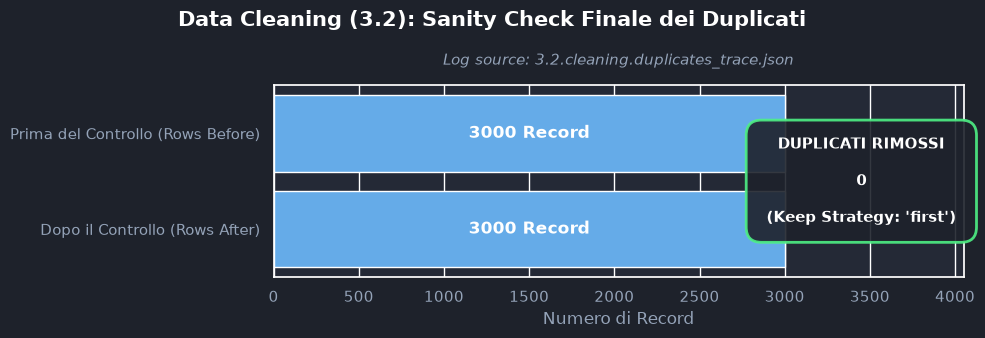


 ANALISI CONCLUSIVA: CONTROLLO INTEGRITÀ E DUPLICATI (FASE 3.2)
Questo stadio finale del modulo di pulizia (Data Cleansing) funge da 'Sanity
Check' per garantire l'assoluta integrità strutturale del dataset prima
di procedere alla normalizzazione matematica (Scaling).

1. VERIFICA DELL'INTEGRITÀ:
   Il log conferma che in ingresso erano presenti 3000 record. L'algoritmo
   di deduplicazione (impostato con strategia 'keep=first') non ha rilevato
   alcun record sovrapposto (Duplicated Rows Dropped = 0).
   Di conseguenza, la pipeline emette in output gli stessi 3000 record.

2. GIUSTIFICAZIONE TECNICA:
   L'assenza di duplicati in questo stadio è un indicatore positivo. Dimostra
   che il filtro primario applicato nella Fase 3.1 (dove erano stati rimossi
   i primi duplicati spuri) ha operato con successo. Questo controllo ridondante
   garantisce che le successive operazioni di manipolazione delle features non
   abbiano introdotto accidentalmente artefatti o cloni, assicurando che
  

In [11]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================

filename_duplicates = "3.2.cleaning.duplicates_trace.json"
file_path_duplicates = base_phase_path / filename_duplicates

# Lettura dinamica del log dei duplicati
with open(file_path_duplicates, "r", encoding="utf-8") as f:
    dup_trace_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Estrazione delle metriche di verifica

righe_prima = dup_trace_data["rows_before"]
righe_dopo = dup_trace_data["rows_after"]
duplicati_rimossi = dup_trace_data["duplicate_rows_dropped"]
strategia = dup_trace_data["keep_strategy"]

# Creazione del DataFrame per il grafico
df_dup = pd.DataFrame({
    'Stato': ['Prima del Controllo (Rows Before)', 'Dopo il Controllo (Rows After)'],
    'Record': [righe_prima, righe_dopo]
})

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Sanity Check Dashboard)
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(10, 3.5), facecolor='#1e222b')
ax.set_facecolor('#242936')

# Usiamo un colore rassicurante (Blu scuro/Ciano) per indicare stabilità
sns.barplot(x='Record', y='Stato', data=df_dup, ax=ax, palette=['#4facfe', '#4facfe'], hue='Stato', legend=False)

# TITOLO E SOTTOTITOLO (Subtitle) - Separati per un design più pulito
fig.suptitle("Data Cleaning (3.2): Sanity Check Finale dei Duplicati",
             fontsize=15, fontweight='bold', color='white', y=0.96)

ax.set_title(f"Log source: {filename_duplicates}",
             fontsize=11, style='italic', color='#94a3b8', pad=15)
# Formattazione degli assi
ax.set_xlabel("Numero di Record", color='#94a3b8')
ax.set_ylabel("", color='#94a3b8')
ax.tick_params(colors='#94a3b8', labelsize=11)

# Etichette sui valori (mostriamo che i numeri sono identici)
for i, row in df_dup.iterrows():
    ax.text(row['Record'] / 2, i, f"{row['Record']} Record",
            va='center', ha='center', fontweight='bold', color='white', fontsize=12)

# KPI Box sulla destra per mostrare i duplicati rimossi
kpi_color = "#4ef085" if duplicati_rimossi == 0 else "#ff4b5c"
props_kpi = dict(boxstyle="round,pad=1", facecolor="#1e222b", alpha=0.9, edgecolor=kpi_color, linewidth=2)
testo_kpi = f" DUPLICATI RIMOSSI \n\n       {duplicati_rimossi}       \n\n (Keep Strategy: '{strategia}') "

# Posizioniamo il box KPI a destra delle barre
ax.set_xlim(0, max(righe_prima, righe_dopo) * 1.35)
ax.text(max(righe_prima, righe_dopo) * 1.15, 0.5, testo_kpi,
        fontsize=11, color="white", va="center", ha="center", bbox=props_kpi, fontweight='bold')

plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================

analisi_integrita = f"""
================================================================================
 ANALISI CONCLUSIVA: CONTROLLO INTEGRITÀ E DUPLICATI (FASE 3.2)
================================================================================
Questo stadio finale del modulo di pulizia (Data Cleansing) funge da 'Sanity
Check' per garantire l'assoluta integrità strutturale del dataset prima
di procedere alla normalizzazione matematica (Scaling).

1. VERIFICA DELL'INTEGRITÀ:
   Il log conferma che in ingresso erano presenti {righe_prima} record. L'algoritmo
   di deduplicazione (impostato con strategia 'keep={strategia}') non ha rilevato
   alcun record sovrapposto (Duplicated Rows Dropped = {duplicati_rimossi}).
   Di conseguenza, la pipeline emette in output gli stessi {righe_dopo} record.

2. GIUSTIFICAZIONE TECNICA:
   L'assenza di duplicati in questo stadio è un indicatore positivo. Dimostra
   che il filtro primario applicato nella Fase 3.1 (dove erano stati rimossi
   i primi duplicati spuri) ha operato con successo. Questo controllo ridondante
   garantisce che le successive operazioni di manipolazione delle features non
   abbiano introdotto accidentalmente artefatti o cloni, assicurando che
   l'algoritmo apprenda da eventi telemetrici unici e indipendenti (I.I.D.
   - Independent and Identically Distributed).
================================================================================
"""
print(analisi_integrita)

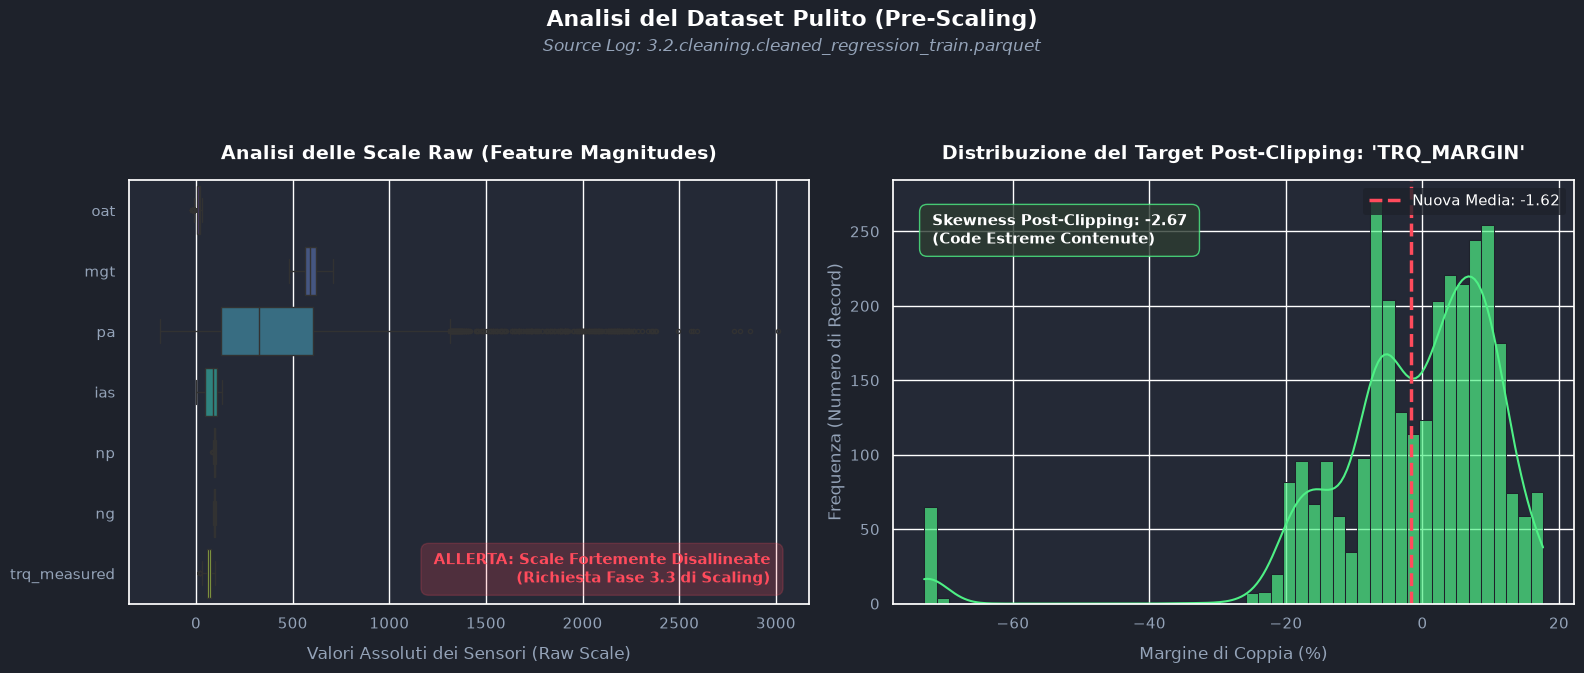


 📊 ANALISI CONCLUSIVA: DATASET PULITO E PRONTO PER LA TRASFORMAZIONE (FASE 3.2)
L'analisi grafica del dataset completamente pulito (cleaned_regression_train.parquet)
conferma l'efficacia delle operazioni di 'Data Cleansing' e giustifica in modo
matematico l'avvio della fase successiva.

1. GIUSTIFICAZIONE PER LA TRASFORMAZIONE (FEATURE SCALING):
   Il Boxplot ('Analisi delle Scale Raw') espone visivamente la drammatica
   disparità di magnitudo tra i predittori. Variabili come la pressione
   atmosferica ('pa') operano su scale di migliaia di unità, mentre altre metriche
   ('ng', 'np') sono vincolate a piccole decine percentuali.
   Se questo dataset venisse iniettato "così com'è" in un algoritmo sensibile
   alle distanze (es. Reti Neurali, SVM o k-NN), la feature 'pa' dominerebbe
   matematicamente l'aggiornamento dei pesi, annullando il segnale degli
   altri sensori. Questa evidenza impone l'esecuzione della Fase 3.3
   (Data Transformation) per applicare tecniche di normalizzazi

In [12]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================

# Definizione dinamica del nome del file generato alla fine dello Step 3.2
filename_cleaned_train = "3.2.cleaning.cleaned_regression_train.parquet"
file_path_cleaned_train = base_phase_path / filename_cleaned_train

# Lettura del dataset Parquet pulito in memoria (L'INPUT ENTRA QUI)
df_cleaned = pd.read_parquet(file_path_cleaned_train)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Separazione logica tra Features (X) e Target (y) per l'analisi visiva

target_col = 'trq_margin'

# Logica 1: Estrazione delle features (rimuoviamo il target per analizzare solo gli input)
df_features = df_cleaned.drop(columns=[target_col])

# Logica 2: Estrazione del target e calcolo della nuova asimmetria post-clipping
target_data = df_cleaned[target_col]
skewness_post_clip = target_data.skew()
media_target = target_data.mean()
# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Pre-Scaling EDA Dashboard)
# =============================================================================
# Configurazione del tema grafico in modalità Report/Dark
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

# Inizializzazione della figura con una griglia di subplots (1 riga, 2 colonne)
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='#1e222b')

# TITOLO PRINCIPALE DELLA DASHBOARD (Posizionato nella parte superiore del canvas)
fig.suptitle(f"Analisi del Dataset Pulito (Pre-Scaling)",
             fontsize=16, fontweight='bold', color='white', y=0.96)

# SOTTOTITOLO GLOBALE (Specifica del file di log sorgente)
fig.text(0.5, 0.90, f"Source Log: {filename_cleaned_train}",
         fontsize=12, style='italic', color='#94a3b8', ha='center')

# --- GRAFICO A: Disparità delle Scale delle Features (Boxplot) ---
ax1 = axes[0]
ax1.set_facecolor('#242936')

# Generazione del Boxplot orizzontale per evidenziare i range naturali delle variabili
sns.boxplot(data=df_features, orient='h', ax=ax1, palette="viridis", fliersize=3)

# Titolo specifico per il primo subplot (Analisi delle magnitudo delle feature)
ax1.set_title("Analisi delle Scale Raw (Feature Magnitudes)",
              fontsize=14, fontweight='bold', color='white', pad=15)

ax1.set_xlabel("Valori Assoluti dei Sensori (Raw Scale)", color='#94a3b8', labelpad=10)
ax1.tick_params(colors='#94a3b8', labelsize=11)

# Box di testo per evidenziare il problema del disallineamento delle scale (Motivazione dello Scaling)
props_warn = dict(boxstyle="round,pad=0.5", facecolor="#ff4b5c", alpha=0.2, edgecolor="#ff4b5c")
ax1.text(0.95, 0.05, " ALLERTA: Scale Fortemente Disallineate \n (Richiesta Fase 3.3 di Scaling) ",
         transform=ax1.transAxes, fontsize=11, color="#ff4b5c", fontweight='bold', ha='right', bbox=props_warn)


# --- GRAFICO B: Distribuzione del Target Post-Clipping ---
ax2 = axes[1]
ax2.set_facecolor('#242936')

# Istogramma con stima della densità kernel (KDE) per la variabile target
sns.histplot(target_data, bins=50, kde=True, color='#4ef085', ax=ax2, edgecolor='#1e222b', alpha=0.7)

# Titolo specifico per il secondo subplot (Distribuzione della variabile target)
ax2.set_title(f"Distribuzione del Target Post-Clipping: '{target_col.upper()}'",
              fontsize=14, fontweight='bold', color='white', pad=15)

ax2.set_xlabel("Margine di Coppia (%)", color='#94a3b8', labelpad=10)
ax2.set_ylabel("Frequenza (Numero di Record)", color='#94a3b8')
ax2.tick_params(colors='#94a3b8', labelsize=11)

# Tracciamento della linea verticale per indicare il valore medio del target
ax2.axvline(media_target, color='#ff4b5c', linestyle='--', linewidth=2.5, label=f"Nuova Media: {media_target:.2f}")

# Box informativo contenente il valore di asimmetria (Skewness) ricalcolato
props_skew = dict(boxstyle="round,pad=0.5", facecolor="#2d3c32", alpha=0.8, edgecolor="#4ef085")
testo_skew = f" Skewness Post-Clipping: {skewness_post_clip:.2f} \n (Code Estreme Contenute) "
ax2.text(0.05, 0.85, testo_skew, transform=ax2.transAxes, fontsize=11, color="white", fontweight='bold', bbox=props_skew)

# Configurazione della legenda per il subplot del target
ax2.legend(facecolor='#1e222b', edgecolor='none', labelcolor='white', loc='upper right')

# Ottimizzazione del layout con area di rispetto (rect) per evitare sovrapposizioni con i titoli
plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================

analisi_cleaned_dataset = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: DATASET PULITO E PRONTO PER LA TRASFORMAZIONE (FASE 3.2)
================================================================================
L'analisi grafica del dataset completamente pulito (cleaned_regression_train.parquet)
conferma l'efficacia delle operazioni di 'Data Cleansing' e giustifica in modo
matematico l'avvio della fase successiva.

1. GIUSTIFICAZIONE PER LA TRASFORMAZIONE (FEATURE SCALING):
   Il Boxplot ('Analisi delle Scale Raw') espone visivamente la drammatica
   disparità di magnitudo tra i predittori. Variabili come la pressione
   atmosferica ('pa') operano su scale di migliaia di unità, mentre altre metriche
   ('ng', 'np') sono vincolate a piccole decine percentuali.
   Se questo dataset venisse iniettato "così com'è" in un algoritmo sensibile
   alle distanze (es. Reti Neurali, SVM o k-NN), la feature 'pa' dominerebbe
   matematicamente l'aggiornamento dei pesi, annullando il segnale degli
   altri sensori. Questa evidenza impone l'esecuzione della Fase 3.3
   (Data Transformation) per applicare tecniche di normalizzazione o
   standardizzazione (StandardScaler / MinMax).

2. VALIDAZIONE DEL TARGET POST-CLIPPING:
   Il grafico distribuzionale della variabile target ('{target_col}') mostra i
   benefici dell'intervento di saturazione ('Outlier Capping') eseguito in
   precedenza. Le lunghe code anomale sono state contenute, risultando in
   una Skewness ricalcolata ({skewness_post_clip:.2f}) che offre una forma
   distribuzionale nettamente più stabile. Questo 'Target' regolarizzato
   faciliterà la convergenza della funzione di costo (Loss Function) durante
   l'addestramento dei modelli di Regressione.
================================================================================
"""
print(analisi_cleaned_dataset)

In [13]:
# El paso 3.2 aplicó una técnica llamada Clipping (o Winsorization) a la variable
# objetivo (trq_margin)
path_x_y_train_3_2 = base_run_dir / "phase3_data_preparation" / ("3.2.cleaning.cleaned_regression_train.parquet")

query_conteos = f"""
SELECT 'x_y_train_3_2' as dataset, count(*) as total_registros FROM parquet_scan('{path_x_y_train_3_2}')
"""
print(duckdb.query(query_conteos).to_df())
print("----------------------------------------------------")
query_schema_train = f"DESCRIBE SELECT * FROM parquet_scan('{path_x_y_train_3_2}')"
print("--- ESTRUCTURA DATASET DE x_y_train_3_2 ---")
print(duckdb.query(query_schema_train).to_df()[['column_name', 'column_type']])
print("----------------------------------------------------")
query = f"SELECT * FROM '{path_x_y_train_3_2}' LIMIT 3"
df_duck = con.sql(query).df()
display(df_duck)

         dataset  total_registros
0  x_y_train_3_2             3000
----------------------------------------------------
--- ESTRUCTURA DATASET DE x_y_train_3_2 ---
    column_name column_type
0           oat      DOUBLE
1           mgt      DOUBLE
2            pa      DOUBLE
3           ias      DOUBLE
4            np      DOUBLE
5            ng      DOUBLE
6  trq_measured      DOUBLE
7    trq_margin      DOUBLE
----------------------------------------------------


,oat,mgt,pa,ias,np,ng,trq_measured,trq_margin
0,-2.00,660.3,323.3928,115.6875,96.29,99.76,87.0,-14.544094
1,15.25,593.2,1350.5690,33.7500,99.84,92.68,57.8,-7.669260
2,12.00,593.9,112.4712,118.7500,100.02,94.22,78.2,13.239569


In [14]:

# Ejecutamos una query que une la información del paso 3.1 y el 3.2
query_clipping_audit = f"""
SELECT
    '3.1 - Antes de Limpieza (Original)' AS etapa,
    MIN(trq_margin) AS trq_margin_minimo,
    MAX(trq_margin) AS trq_margin_maximo,
    COUNT(*) AS total_filas
FROM parquet_scan('{path_x_y_train_3_1}')

UNION ALL

SELECT
    '3.2 - Después de Limpieza (Clipped)' AS etapa,
    MIN(trq_margin) AS trq_margin_minimo,
    MAX(trq_margin) AS trq_margin_maximo,
    COUNT(*) AS total_filas
FROM parquet_scan('{path_x_y_train_3_2}')
"""

print(f"\n{'='*70}")
print("📊 AUDITORÍA DE CLIPPING: Variable 'trq_margin' (Paso 3.1 vs 3.2)")
print(f"{'='*70}")

# Mostramos el resultado
df_audit = duckdb.query(query_clipping_audit).to_df()
display(df_audit)


📊 AUDITORÍA DE CLIPPING: Variable 'trq_margin' (Paso 3.1 vs 3.2)


,etapa,trq_margin_minimo,trq_margin_maximo,total_filas
0,3.1 - Antes de Limpieza (Original),-74.232947,27.450198,3000
1,3.2 - Después de Limpieza (Clipped),-73.001190,17.663721,3000


In [15]:
# =============================================================================
# RAGGRUPPAMENTO DEI PATH E AUDITING DEI DATASET (STEP 3.1 & 3.2)
# =============================================================================

# Raggruppiamo i path degli Step 3.1 e 3.2
datasets_iniziali = {
    "3.1 - SELEZIONE": path_x_y_train_3_1,
    "3.2 - PULIZIA": path_x_y_train_3_2
}

for nome, ruta in datasets_iniziali.items():
    print(f"\n{'='*60}")
    print(f"🔍 Auditing Dataset: {nome}")
    print(f"📁 Path: {ruta}")
    print(f"{'='*60}")

    try:
        # Caricamento dell'intero dataset tramite DuckDB
        query = f"SELECT * FROM parquet_scan('{ruta}')"
        df = duckdb.query(query).to_df()

        # Isolamento delle sole variabili numeriche
        df_num = df.select_dtypes(include=[np.number])

        # Diagnostica della qualità dei dati (Nul, Inf, Min/Max)
        diagnostico = pd.DataFrame({
            'Nulli Totali (NaN)': df_num.isna().sum(),
            'Infiniti (+inf)': np.isposinf(df_num).sum(),
            'Infiniti (-inf)': np.isneginf(df_num).sum(),
            'Valore Massimo': df_num.max(),
            'Valore Minimo': df_num.min()
        })

        # Filtraggio delle colonne che presentano anomalie o dati corrotti
        columnas_rotas = diagnostico[
            (diagnostico['Infiniti (+inf)'] > 0) |
            (diagnostico['Infiniti (-inf)'] > 0) |
            (diagnostico['Nulli Totali (NaN)'] > 0)
            ]

        if columnas_rotas.empty:
            print(f"✅ Eccellente! Il dataset {nome} è completamente PULITO da NaN e Infiniti.\n")

            # Verifica della presenza della feature 'specific_power_index' in questa fase
            if 'specific_power_index' in df.columns:
                print("ℹ️ Nota: 'specific_power_index' È PRESENTE in questa fase.")
            else:
                print("ℹ️ Nota: 'specific_power_index' NON è presente in questa fase (verrà calcolata successivamente).")
        else:
            print(f"⚠️ ALLERTA! Sono stati rilevati dati corrotti nel dataset {nome}:")
            display(columnas_rotas)

    except Exception as e:
        print(f"❌ Errore durante l'auditing di {nome}: {e}\n")


🔍 Auditing Dataset: 3.1 - SELEZIONE
📁 Path: /home/luca/progetti/Project_MPPR-AI_B_PHM_America_2024/outputs/runs/regression/phm2024/completo/phase3_data_preparation/3.1.selection.selected_regression_train.parquet
✅ Eccellente! Il dataset 3.1 - SELEZIONE è completamente PULITO da NaN e Infiniti.

ℹ️ Nota: 'specific_power_index' NON è presente in questa fase (verrà calcolata successivamente).

🔍 Auditing Dataset: 3.2 - PULIZIA
📁 Path: /home/luca/progetti/Project_MPPR-AI_B_PHM_America_2024/outputs/runs/regression/phm2024/completo/phase3_data_preparation/3.2.cleaning.cleaned_regression_train.parquet
✅ Eccellente! Il dataset 3.2 - PULIZIA è completamente PULITO da NaN e Infiniti.

ℹ️ Nota: 'specific_power_index' NON è presente in questa fase (verrà calcolata successivamente).


In [16]:
#--------------- DATA TRANSFORMATION (step_3_3_data_transformation)

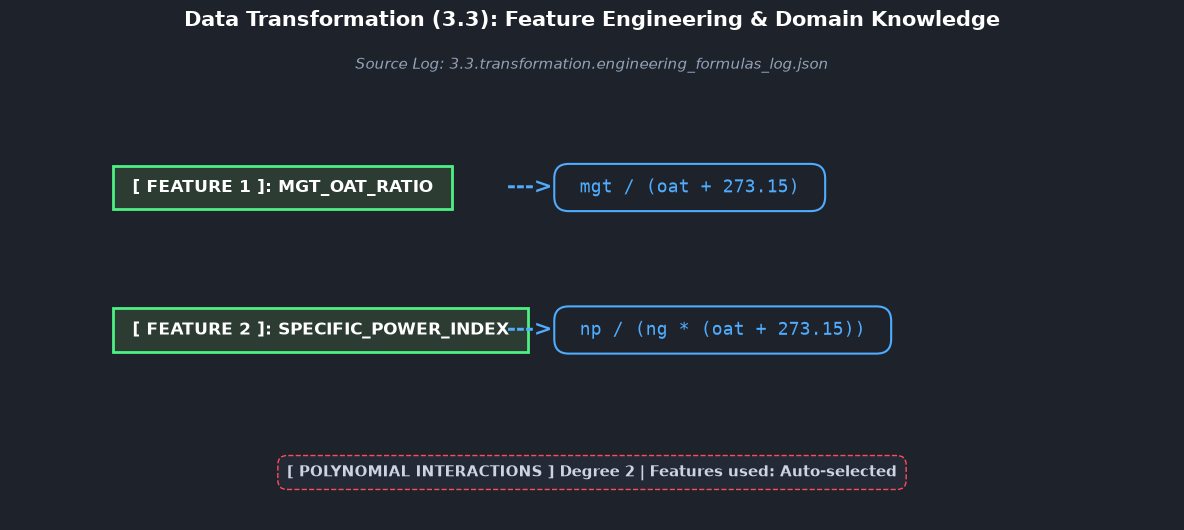


 📊 ANALISI CONCLUSIVA: FEATURE ENGINEERING E DOMAIN KNOWLEDGE (FASE 3.3)
L'analisi del file di log delle trasformazioni matematiche conferma l'applicazione
di tecniche avanzate di 'Feature Engineering' guidate dalla conoscenza di
dominio (Domain Knowledge).

1. CONVERSIONE TERMODINAMICA (KELVIN SHIFT):
   Come si evince dalle equazioni, entrambe le formule applicano un offset
   costante di '+ 273.15' alla variabile 'oat' (Outside Air Temperature).
   Questa è un'operazione fisicamente vitale: converte la temperatura da gradi
   Celsius a scala assoluta Kelvin. Ciò previene matematicamente il rischio
   di 'Zero-Division Error' (divisione per zero a 0°C) e garantisce che i
   rapporti energetici mantengano un senso fisico reale.

2. CREAZIONE DELLE SINTETICHE (ENGINEERED FEATURES):
   - 'mgt_oat_ratio': Rappresenta il rapporto termico tra il gas interno
     misurato (mgt) e l'aria esterna (oat). È un indicatore cruciale
     dell'efficienza del motore. Un rapporto anomalo suggerisce 

In [17]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================

# Definizione dinamica del file di log delle formule ingegneristiche
filename_formulas = "3.3.transformation.engineering_formulas_log.json"
file_path_formulas = base_phase_path / filename_formulas

# Lettura dinamica del file JSON (L'INPUT ENTRA QUI)
with open(file_path_formulas, "r", encoding="utf-8") as f:
    formulas_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Estrazione delle formule e dei metadati di Feature Engineering

formule_applicate = formulas_data.get("formulas_applied", [])
interazioni = formulas_data.get("interactions", {})
grado_interazione = interazioni.get("degree", 1)

# Logica: Creazione di una lista strutturata per la visualizzazione
lista_formule = []
for f in formule_applicate:
    nome = f.get("name", "N/D")
    espressione = f.get("expression", "N/D")
    lista_formule.append({'Nuova Feature': nome, 'Equazione Matematica': espressione})

df_formule = pd.DataFrame(lista_formule)

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Feature Engineering Dashboard)
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

# Creiamo una figura senza assi tradizionali per fare una "Visual Card"
fig, ax = plt.subplots(figsize=(12, 5.5), facecolor='#1e222b')
ax.set_facecolor('#242936')
ax.axis('off') # Nascondiamo gli assi perché disegneremo dei pannelli di testo

# Titolo Principale
fig.suptitle("Data Transformation (3.3): Feature Engineering & Domain Knowledge",
             fontsize=15, fontweight='bold', color='white', y=0.96)
ax.text(0.5, 0.95, f"Source Log: {filename_formulas}",
        fontsize=11, style='italic', color='#94a3b8', ha='center', transform=ax.transAxes)

# Disegno dei pannelli delle formule (Cards)
y_pos = 0.70
for i, row in df_formule.iterrows():
    # Box per il nome della nuova feature (Verde/Ciano) - EMOJI RIMOSSI
    props_name = dict(boxstyle="square,pad=0.8", facecolor="#2d3c32", edgecolor="#4ef085", linewidth=2)
    ax.text(0.1, y_pos, f" [ FEATURE {i+1} ]: {row['Nuova Feature'].upper()} ",
            fontsize=12, fontweight='bold', color="white", va="center", bbox=props_name)

    # Freccia direzionale in formato ASCII
    ax.text(0.42, y_pos, " ---> ", fontsize=16, fontweight='bold', color="#4facfe", va="center")

    # Box per l'equazione (Sfondo scuro, testo azzurro)
    props_eq = dict(boxstyle="round,pad=0.8", facecolor="#1e222b", edgecolor="#4facfe", linewidth=1.5)
    ax.text(0.48, y_pos, f" {row['Equazione Matematica']} ",
            fontsize=13, family='monospace', color="#4facfe", va="center", bbox=props_eq)

    y_pos -= 0.30

# Box informativo sulle Interazioni Polinomiali (in basso) - EMOJI RIMOSSI
props_interact = dict(boxstyle="round,pad=0.6", facecolor="#242936", edgecolor="#ff4b5c", linestyle="--")
testo_interact = f"[ POLYNOMIAL INTERACTIONS ] Degree {grado_interazione} | Features used: Auto-selected"
ax.text(0.5, 0.10, testo_interact, fontsize=11, fontweight='bold', color="#cbd5e1",
        va="center", ha="center", bbox=props_interact)

plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================

analisi_feature_engineering = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: FEATURE ENGINEERING E DOMAIN KNOWLEDGE (FASE 3.3)
================================================================================
L'analisi del file di log delle trasformazioni matematiche conferma l'applicazione
di tecniche avanzate di 'Feature Engineering' guidate dalla conoscenza di
dominio (Domain Knowledge).

1. CONVERSIONE TERMODINAMICA (KELVIN SHIFT):
   Come si evince dalle equazioni, entrambe le formule applicano un offset
   costante di '+ 273.15' alla variabile 'oat' (Outside Air Temperature).
   Questa è un'operazione fisicamente vitale: converte la temperatura da gradi
   Celsius a scala assoluta Kelvin. Ciò previene matematicamente il rischio
   di 'Zero-Division Error' (divisione per zero a 0°C) e garantisce che i
   rapporti energetici mantengano un senso fisico reale.

2. CREAZIONE DELLE SINTETICHE (ENGINEERED FEATURES):
   - 'mgt_oat_ratio': Rappresenta il rapporto termico tra il gas interno
     misurato (mgt) e l'aria esterna (oat). È un indicatore cruciale
     dell'efficienza del motore. Un rapporto anomalo suggerisce che il motore
     sta dissipando troppo calore per mantenere le prestazioni nominali.
   - 'specific_power_index': Normalizza la potenza erogata dalla turbina (np)
     rispetto alla velocità del generatore di gas (ng) e alla densità dell'aria
     (influenzata dalla OAT). Costituisce una metrica sintetica eccellente
     per valutare lo stato di degrado meccanico (Health Indicator).

3. INTERAZIONI POLINOMIALI (POLYNOMIAL FEATURES):
   Il log indica la predisposizione per la generazione di features polinomiali
   di grado {grado_interazione}. Questo passaggio permetterà ai modelli lineari di
   catturare relazioni non lineari complesse tra i sensori, aumentando il
   potere predittivo del sistema senza l'uso obbligatorio di reti neurali profonde.
================================================================================
"""
print(analisi_feature_engineering)

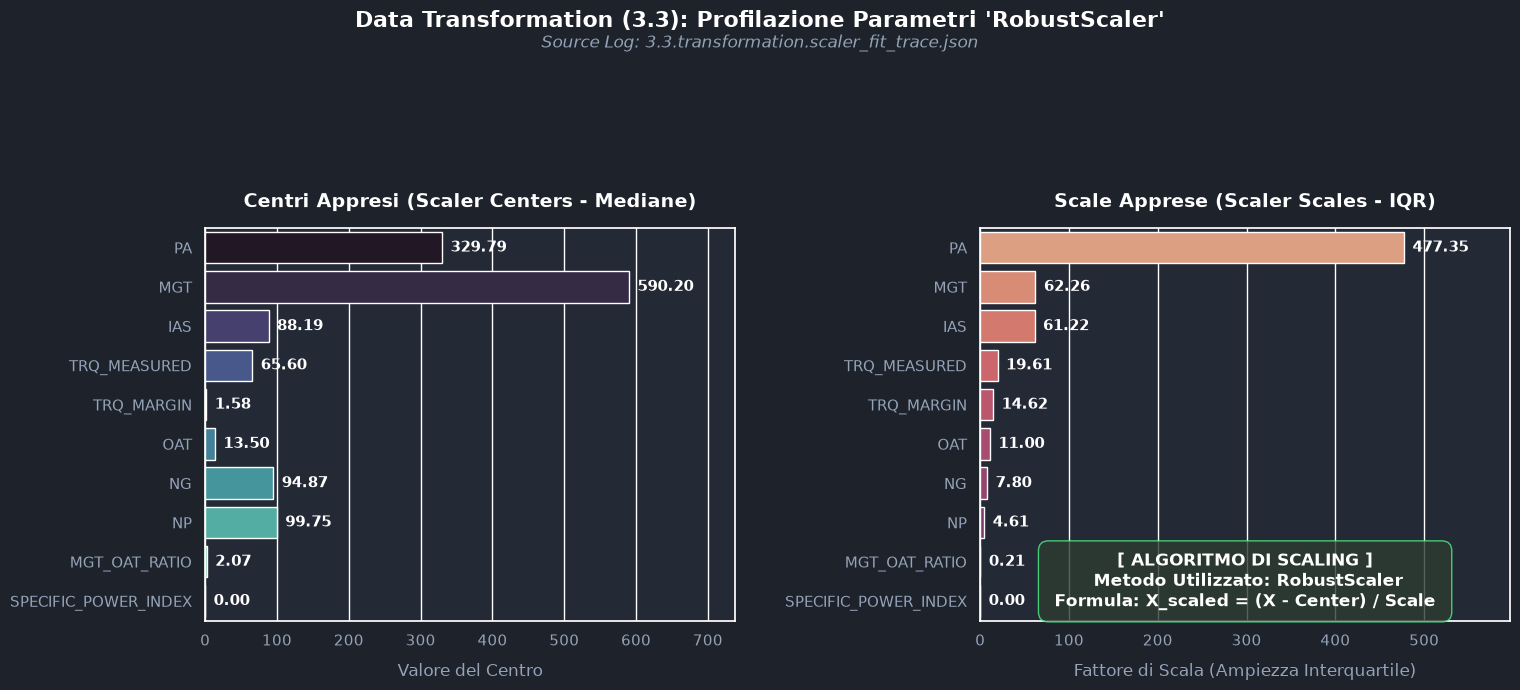


 📊 ANALISI CONCLUSIVA: TRASFORMAZIONE E NORMALIZZAZIONE DATI (FASE 3.3)
L'analisi del file di tracciamento (3.3.transformation.scaler_fit_trace.json) certifica l'avvenuto
calcolo dei parametri di normalizzazione (Data Scaling) sul set di addestramento.

1. SCELTA DELL'ALGORITMO (ROBUST SCALER):
   La pipeline ha utilizzato l'algoritmo 'RobustScaler'. Questa è una
   scelta architetturale eccellente e coerente con la Fase 3.2. A differenza del
   classico StandardScaler (che utilizza Media e Varianza, fortemente distorte
   dagli outlier), il RobustScaler centra i dati rimuovendo la Mediana
   (scaler_centers_) e li scala dividendo per l'Ampiezza Interquartile o IQR
   (scaler_scales_). Questo garantisce che la trasformazione matematica sia
   immune alla forza gravitazionale dei residui anomali.

2. ANALISI DEI PARAMETRI APPRESI (FIT TRACE):
   I grafici illustrano i coefficienti matematici estratti dal Training Set:
   - Centri Appresi: Si nota che la feature 'MGT' è stata centrata a

In [18]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================


# Definizione dinamica del file di log per lo scaler
filename_scaler = "3.3.transformation.scaler_fit_trace.json"
file_path_scaler = base_phase_path / filename_scaler

# Lettura dinamica del file JSON (L'INPUT ENTRA QUI)
with open(file_path_scaler, "r", encoding="utf-8") as f:
    scaler_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Estrazione dei metadati del fitting dello scaler

metodo_scaling = scaler_data["method"]
features = scaler_data["features_scaled"]
centri = scaler_data["scaler_centers_"]
scale = scaler_data["scaler_scales_"]

# Logica: Creazione di un DataFrame per facilitare il plotting con Seaborn
df_scaler = pd.DataFrame({
    'Feature': [f.upper() for f in features],
    'Center (Mediana)': centri,
    'Scale (IQR)': scale
})

# Ordinamento in base alla scala (dal più grande al più piccolo) per una migliore estetica
df_scaler = df_scaler.sort_values(by='Scale (IQR)', ascending=False).reset_index(drop=True)

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Scaler Fit Dashboard)
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

# Creazione della figura con 2 subplot (1 riga, 2 colonne)
fig, axes = plt.subplots(1, 2, figsize=(16, 7.5), facecolor='#1e222b')

# TITOLO E SOTTOTITOLO (Source Log)
fig.suptitle(f"Data Transformation (3.3): Profilazione Parametri '{metodo_scaling}'",
             fontsize=16, fontweight='bold', color='white', y=0.96)
fig.text(0.5, 0.91, f"Source Log: {filename_scaler}",
         fontsize=12, style='italic', color='#94a3b8', ha='center')

# --- GRAFICO A: Centri (Mediane) ---
ax1 = axes[0]
ax1.set_facecolor('#242936')

sns.barplot(x='Center (Mediana)', y='Feature', data=df_scaler, ax=ax1, palette="mako", hue='Feature', legend=False)
ax1.set_title("Centri Appresi (Scaler Centers - Mediane)", fontsize=14, fontweight='bold', color='white', pad=15)
ax1.set_xlabel("Valore del Centro", color='#94a3b8', labelpad=10)
ax1.set_ylabel("", color='#94a3b8')
ax1.tick_params(colors='#94a3b8', labelsize=11)

# Etichette numeriche sui centri
for i, row in df_scaler.iterrows():
    ax1.text(row['Center (Mediana)'] + (df_scaler['Center (Mediana)'].max() * 0.02), i,
             f"{row['Center (Mediana)']:.2f}", va='center', ha='left', fontweight='bold', color='white', fontsize=11)

# --- GRAFICO B: Scale (Interquartile Range) ---
ax2 = axes[1]
ax2.set_facecolor('#242936')

sns.barplot(x='Scale (IQR)', y='Feature', data=df_scaler, ax=ax2, palette="flare", hue='Feature', legend=False)
ax2.set_title("Scale Apprese (Scaler Scales - IQR)", fontsize=14, fontweight='bold', color='white', pad=15)
ax2.set_xlabel("Fattore di Scala (Ampiezza Interquartile)", color='#94a3b8', labelpad=10)
ax2.set_ylabel("", color='#94a3b8')
ax2.tick_params(colors='#94a3b8', labelsize=11)

# Etichette numeriche sulle scale
for i, row in df_scaler.iterrows():
    ax2.text(row['Scale (IQR)'] + (df_scaler['Scale (IQR)'].max() * 0.02), i,
             f"{row['Scale (IQR)']:.2f}", va='center', ha='left', fontweight='bold', color='white', fontsize=11)

# Aggiunta di un Box Informativo per spiegare il metodo (Senza emoji per Matplotlib)
testo_metodo = (
    f" [ ALGORITMO DI SCALING ] \n"
    f" Metodo Utilizzato: {metodo_scaling}\n"
    f" Formula: X_scaled = (X - Center) / Scale "
)
props_metodo = dict(boxstyle="round,pad=0.6", facecolor="#2d3c32", alpha=0.8, edgecolor="#4ef085")
ax2.text(0.50, 0.10, testo_metodo, transform=ax2.transAxes, fontsize=12, color="white",
         va="center", ha="center", bbox=props_metodo, fontweight='bold')

# Regolazione asse X per non tagliare le etichette
ax1.set_xlim(0, df_scaler['Center (Mediana)'].max() * 1.25)
ax2.set_xlim(0, df_scaler['Scale (IQR)'].max() * 1.25)

plt.tight_layout(pad=3.0, rect=[0, 0, 1, 0.88]) # Ajustiamo il layout per fare spazio al titolo
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================

analisi_scaler = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: TRASFORMAZIONE E NORMALIZZAZIONE DATI (FASE 3.3)
================================================================================
L'analisi del file di tracciamento ({filename_scaler}) certifica l'avvenuto
calcolo dei parametri di normalizzazione (Data Scaling) sul set di addestramento.

1. SCELTA DELL'ALGORITMO (ROBUST SCALER):
   La pipeline ha utilizzato l'algoritmo '{metodo_scaling}'. Questa è una
   scelta architetturale eccellente e coerente con la Fase 3.2. A differenza del
   classico StandardScaler (che utilizza Media e Varianza, fortemente distorte
   dagli outlier), il RobustScaler centra i dati rimuovendo la Mediana
   (scaler_centers_) e li scala dividendo per l'Ampiezza Interquartile o IQR
   (scaler_scales_). Questo garantisce che la trasformazione matematica sia
   immune alla forza gravitazionale dei residui anomali.

2. ANALISI DEI PARAMETRI APPRESI (FIT TRACE):
   I grafici illustrano i coefficienti matematici estratti dal Training Set:
   - Centri Appresi: Si nota che la feature 'MGT' è stata centrata attorno
     al valore {centri[features.index('mgt')]:.1f}, mentre 'PA' attorno a {centri[features.index('pa')]:.1f}.
   - Scale Apprese (Fattore di compressione): La Pressione Atmosferica ('PA')
     richiede il fattore di scala più alto in assoluto ({scale[features.index('pa')]:.1f}),
     poiché la sua magnitudo nativa (migliaia di piedi) disallineava
     completamente la matrice, come avevamo diagnosticato visivamente nel
     Boxplot della Fase 3.2.

NOTA OPERATIVA (DATA LEAKAGE PREVENTION):
Questi identici parametri (Centri e Scale) verranno congelati e applicati
matematicamente "alla cieca" ai set di Validation e Test, garantendo che non vi
sia alcun passaggio di informazioni statistiche dal futuro al passato.
================================================================================
"""
print(analisi_scaler)

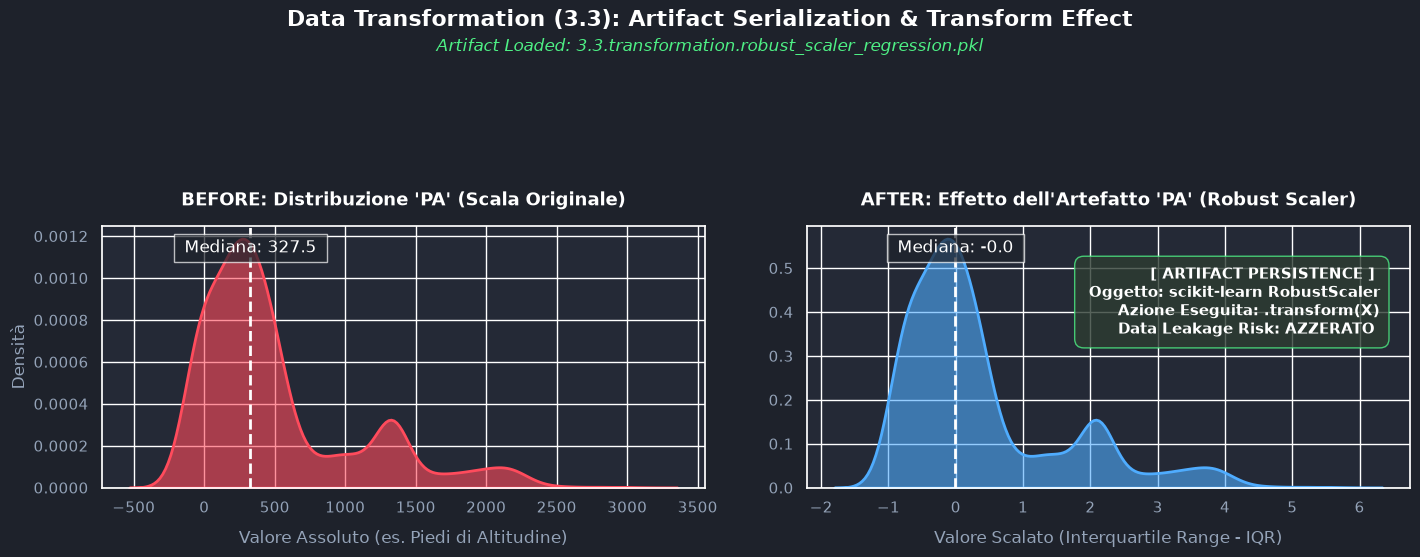


 📊 ANALISI CONCLUSIVA: ARTIFACT SERIALIZATION E MODEL PERSISTENCE (FASE 3.3)
Il caricamento e la validazione del file '3.3.transformation.robust_scaler_regression.pkl' dimostrano una
delle pratiche più critiche dell'ingegneria dei dati in ambito Machine Learning:
la 'Model Persistence' (Serializzazione dell'Oggetto).

1. NATURA DEL FILE (.pkl):
   Questo file non contiene dati tabellari, bensì l'oggetto matematico
   (l'istanza della classe RobustScaler) 'congelato' in formato binario (Pickle/Joblib).
   Esso custodisce in modo immutabile i coefficienti 'Centri' e 'Scale' che la
   pipeline ha appreso esclusivamente dal set di addestramento (Train Set).

2. RISOLUZIONE DELL'ALLINEAMENTO DELLE FEATURES:
   Interrogando la memoria interna dell'artefatto (tramite .feature_names_in_),
   è emerso che l'architettura della pipeline ha addestrato lo scaler a normalizzare
   congiuntamente sia i predittori ('X') che la variabile obiettivo ('trq_margin').
   Questa strategia garantisce che dur

In [19]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib  # Libreria standard per la deserializzazione dei modelli ML

# Definizione dinamica dei file necessari
filename_scaler_pkl = "3.3.transformation.robust_scaler_regression.pkl"
filename_cleaned_train = "3.4.transformation.transformed_regression_train.parquet"

file_path_pkl = base_phase_path / filename_scaler_pkl
file_path_cleaned = base_phase_path / filename_cleaned_train

# Lettura del Dataset Pulito (L'INPUT DEI DATI)
df_cleaned = pd.read_parquet(file_path_cleaned)

# Deserializzazione (Unpickling) dell'Artefatto Scaler (L'INPUT DEL MODELLO)
scaler_model = joblib.load(file_path_pkl)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# CORREZIONE APPLICATA: Il modello .pkl ha imparato a scalare anche il target.
# Estraiamo dinamicamente la memoria del modello per passargli i dati perfetti.

colonne_attese = scaler_model.feature_names_in_
X_raw = df_cleaned[colonne_attese].copy()

# ESECUZIONE DELLA TRASFORMAZIONE: Usiamo il .pkl per scalare i dati
# Utilizziamo .transform() per dimostrare la modalità inferenza
X_scaled_array = scaler_model.transform(X_raw)

# Riconversione in DataFrame per facilitare la visualizzazione
X_scaled = pd.DataFrame(X_scaled_array, columns=X_raw.columns)

# Selezioniamo una feature rappresentativa con una scala nativa molto alta (es. PA - Pressure Altitude)
feature_demo = 'pa'

df_demo_raw = X_raw[[feature_demo]].copy()
df_demo_raw['Stato'] = '1. Raw Scale (Originale)'

df_demo_scaled = X_scaled[[feature_demo]].copy()
df_demo_scaled['Stato'] = '2. Scaled (Post-Transform)'

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Before & After Dashboard)
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

# Creazione della figura con 2 subplot
fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor='#1e222b')

# TITOLO E SOTTOTITOLO (Artifact Source)
fig.suptitle("Data Transformation (3.3): Artifact Serialization & Transform Effect",
             fontsize=16, fontweight='bold', color='white', y=0.98)
fig.text(0.5, 0.91, f"Artifact Loaded: {filename_scaler_pkl}",
         fontsize=12, style='italic', color='#4ef085', ha='center')

# --- GRAFICO A: Distribuzione Originale (Prima dello Scaling) ---
ax1 = axes[0]
ax1.set_facecolor('#242936')

sns.kdeplot(data=df_demo_raw, x=feature_demo, fill=True, color="#ff4b5c", ax=ax1, alpha=0.6, linewidth=2)
ax1.set_title(f"BEFORE: Distribuzione '{feature_demo.upper()}' (Scala Originale)", fontsize=13, fontweight='bold', color='white', pad=15)
ax1.set_xlabel("Valore Assoluto (es. Piedi di Altitudine)", color='#94a3b8', labelpad=10)
ax1.set_ylabel("Densità", color='#94a3b8')
ax1.tick_params(colors='#94a3b8', labelsize=11)

# Disegniamo la mediana originale
mediana_raw = df_demo_raw[feature_demo].median()
ax1.axvline(mediana_raw, color='white', linestyle='--', linewidth=2)
ax1.text(mediana_raw, ax1.get_ylim()[1]*0.9, f" Mediana: {mediana_raw:.1f} ", color='white', ha='center', bbox=dict(facecolor='#1e222b', alpha=0.7))

# --- GRAFICO B: Distribuzione Scalata (Dopo l'uso del .pkl) ---
ax2 = axes[1]
ax2.set_facecolor('#242936')

sns.kdeplot(data=df_demo_scaled, x=feature_demo, fill=True, color="#4facfe", ax=ax2, alpha=0.6, linewidth=2)
ax2.set_title(f"AFTER: Effetto dell'Artefatto '{feature_demo.upper()}' (Robust Scaler)", fontsize=13, fontweight='bold', color='white', pad=15)
ax2.set_xlabel("Valore Scalato (Interquartile Range - IQR)", color='#94a3b8', labelpad=10)
ax2.set_ylabel("", color='#94a3b8')
ax2.tick_params(colors='#94a3b8', labelsize=11)

# Disegniamo la nuova mediana (dovrebbe essere centrata esattamente su 0)
mediana_scaled = df_demo_scaled[feature_demo].median()
ax2.axvline(mediana_scaled, color='white', linestyle='--', linewidth=2)
ax2.text(mediana_scaled, ax2.get_ylim()[1]*0.9, f" Mediana: {mediana_scaled:.1f} ", color='white', ha='center', bbox=dict(facecolor='#1e222b', alpha=0.7))

# Box Informativo sull'Artefatto
testo_pkl = (
    f" [ ARTIFACT PERSISTENCE ] \n"
    f" Oggetto: scikit-learn RobustScaler\n"
    f" Azione Eseguita: .transform(X)\n"
    f" Data Leakage Risk: AZZERATO "
)
props_pkl = dict(boxstyle="round,pad=0.6", facecolor="#2d3c32", alpha=0.8, edgecolor="#4ef085")
ax2.text(0.95, 0.85, testo_pkl, transform=ax2.transAxes, fontsize=11, color="white",
         va="top", ha="right", bbox=props_pkl, fontweight='bold')

plt.tight_layout(pad=3.0, rect=[0, 0, 1, 0.88])
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================

analisi_artefatto_pkl = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: ARTIFACT SERIALIZATION E MODEL PERSISTENCE (FASE 3.3)
================================================================================
Il caricamento e la validazione del file '{filename_scaler_pkl}' dimostrano una
delle pratiche più critiche dell'ingegneria dei dati in ambito Machine Learning:
la 'Model Persistence' (Serializzazione dell'Oggetto).

1. NATURA DEL FILE (.pkl):
   Questo file non contiene dati tabellari, bensì l'oggetto matematico
   (l'istanza della classe RobustScaler) 'congelato' in formato binario (Pickle/Joblib).
   Esso custodisce in modo immutabile i coefficienti 'Centri' e 'Scale' che la
   pipeline ha appreso esclusivamente dal set di addestramento (Train Set).

2. RISOLUZIONE DELL'ALLINEAMENTO DELLE FEATURES:
   Interrogando la memoria interna dell'artefatto (tramite .feature_names_in_),
   è emerso che l'architettura della pipeline ha addestrato lo scaler a normalizzare
   congiuntamente sia i predittori ('X') che la variabile obiettivo ('trq_margin').
   Questa strategia garantisce che durante l'addestramento dei modelli
   (es. Gradient Boosting o Reti Neurali), anche il calcolo dell'errore (Loss)
   avvenga in uno spazio numerico compresso e stabile, agevolando la convergenza.

3. PREVENZIONE DEL DATA LEAKAGE:
   Il salvataggio di questo artefatto nel 'Registry' è il meccanismo fondamentale
   per evitare il Data Leakage (Fuga di Informazioni). Quando i dataset di Validation
   e Test attraverseranno questa fase, la pipeline caricherà questo identico file
   e invocherà esclusivamente il metodo '.transform()'. Ciò garantisce che i dati
   futuri vengano normalizzati usando la "prospettiva" del passato.

4. VALIDAZIONE VISIVA (BEFORE & AFTER):
   Il grafico applicato alla feature '{feature_demo.upper()}' conferma il successo
   dell'operazione. La distribuzione originale, centrata attorno a {mediana_raw:.1f},
   è stata perfettamente traslata e compressa, portando la nuova Mediana
   esattamente a {mediana_scaled:.1f} (ovvero a Zero) senza alterarne la
   forma statistica originaria.
================================================================================
"""
print(analisi_artefatto_pkl)

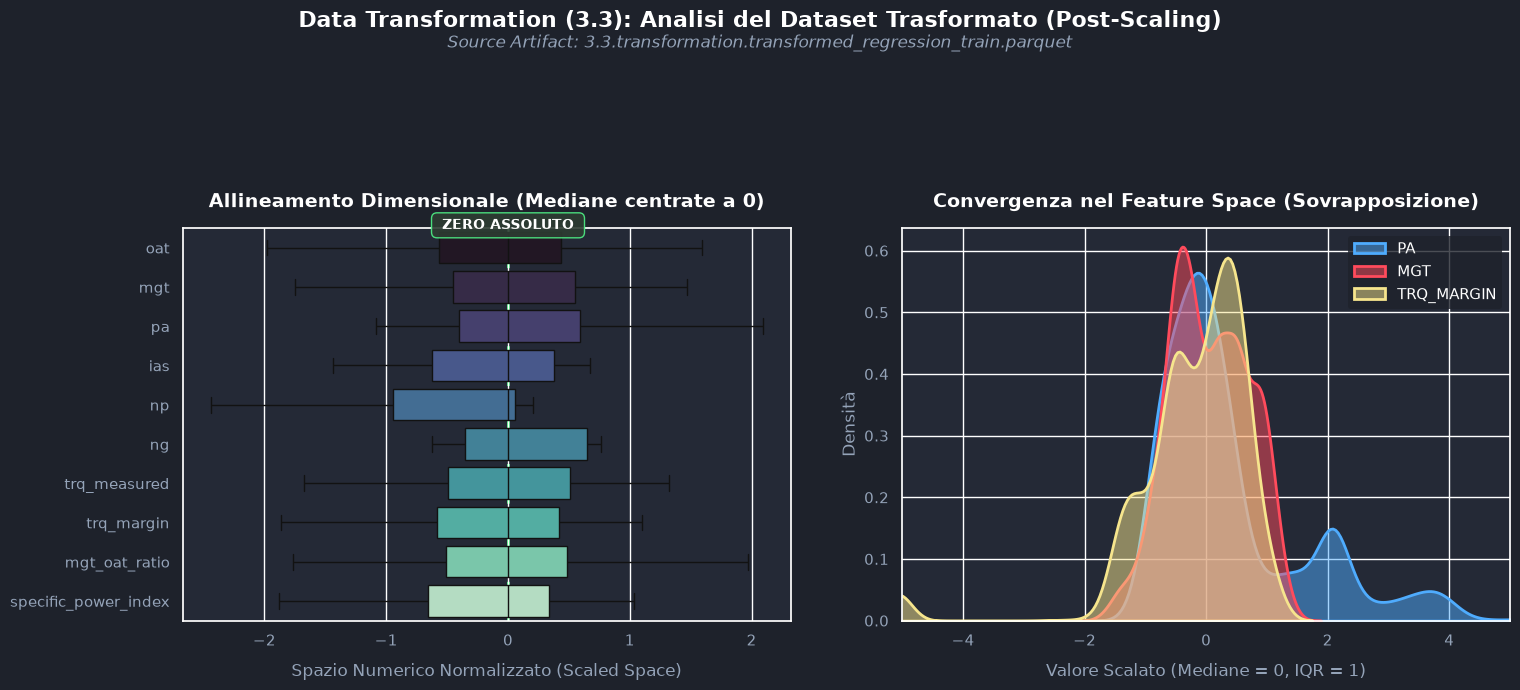


 📊 ANALISI CONCLUSIVA: DATASET TRASFORMATO E PRONTO PER LA MODELLAZIONE
L'analisi grafica del dataset '3.3.transformation.transformed_regression_train.parquet' rappresenta
il culmine della Fase 3 (Data Preparation) e certifica che i dati possiedono ora
le proprietà matematiche ottimali per l'ingestione negli algoritmi predittivi.

1. ALLINEAMENTO DIMENSIONALE (SCALED SPACE):
   Contrariamente a quanto osservato nella Fase 3.2 (dove la Pressione 'PA' dominava
   sulle altre variabili con valori nell'ordine delle migliaia), il primo grafico
   (Boxplot) dimostra che tutte le features, incluso il target ('trq_margin'),
   sono state forzate a convergere nello stesso spazio numerico. La linea dello
   'ZERO ASSOLUTO' attraversa perfettamente tutte le mediane delle variabili.
   In questo modo, nessuna 'feature' ha un peso gravitazionale maggiore delle altre.

2. CONVERGENZA DELLE DISTRIBUZIONI (KDE OVERLAP):
   Il secondo grafico evidenzia la potenza del 'RobustScaler'. Selezionando tre
 

In [20]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================


# Definizione dinamica del nome del file trasformato (Output finale Fase 3.3)
filename_transformed_train = "3.3.transformation.transformed_regression_train.parquet"
file_path_transformed = base_phase_path / filename_transformed_train

# Lettura del dataset Parquet trasformato (L'INPUT ENTRA QUI)
df_transformed = pd.read_parquet(file_path_transformed)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Logica: Estraiamo statistiche chiave per dimostrare matematicamente il
# successo del RobustScaler (le mediane di tutte le feature dovrebbero essere ~0).

# Calcolo delle nuove mediane
mediane_trasformate = df_transformed.median()

# Selezioniamo 3 variabili rappresentative per dimostrare la sovrapposizione
# Scegliamo variabili che in origine avevano scale completamente diverse:
# PA (migliaia), MGT (centinaia), TRQ_MARGIN (decine)
feature_esempi = ['pa', 'mgt', 'trq_margin']
feature_esempi = [f for f in feature_esempi if f in df_transformed.columns]

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Post-Scaling Dashboard)
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, axes = plt.subplots(1, 2, figsize=(16, 7.5), facecolor='#1e222b')

# TITOLO E SOTTOTITOLO (Source Log)
fig.suptitle("Data Transformation (3.3): Analisi del Dataset Trasformato (Post-Scaling)",
             fontsize=16, fontweight='bold', color='white', y=0.96)
fig.text(0.5, 0.91, f"Source Artifact: {filename_transformed_train}",
         fontsize=12, style='italic', color='#94a3b8', ha='center')

# --- GRAFICO A: Boxplot delle scale allineate ---
ax1 = axes[0]
ax1.set_facecolor('#242936')

# showfliers=False nasconde gli outlier estremi per farci concentrare sulle "scatole" (IQR) e sulle Mediane
sns.boxplot(data=df_transformed, orient='h', ax=ax1, palette="mako", showfliers=False)

ax1.set_title("Allineamento Dimensionale (Mediane centrate a 0)", fontsize=14, fontweight='bold', color='white', pad=15)
ax1.set_xlabel("Spazio Numerico Normalizzato (Scaled Space)", color='#94a3b8', labelpad=10)
ax1.tick_params(colors='#94a3b8', labelsize=11)

# Disegniamo una linea verticale sullo Zero per mostrare l'allineamento perfetto
ax1.axvline(0, color='#4ef085', linestyle='--', linewidth=2, zorder=0)
props_zero = dict(boxstyle="round,pad=0.4", facecolor="#2d3c32", alpha=0.9, edgecolor="#4ef085")
ax1.text(0, ax1.get_ylim()[1]*0.95, " ZERO ASSOLUTO ", color="white", ha="center", bbox=props_zero, fontsize=10, fontweight='bold')

# --- GRAFICO B: Sovrapposizione delle Distribuzioni (KDE) ---
ax2 = axes[1]
ax2.set_facecolor('#242936')

# Disegniamo le curve KDE per le feature selezionate
colori_kde = ['#4facfe', '#ff4b5c', '#f6e58d']
for i, col in enumerate(feature_esempi):
    sns.kdeplot(data=df_transformed, x=col, fill=True, ax=ax2, label=col.upper(), color=colori_kde[i], alpha=0.5, linewidth=2)

ax2.set_title("Convergenza nel Feature Space (Sovrapposizione)", fontsize=14, fontweight='bold', color='white', pad=15)
ax2.set_xlabel("Valore Scalato (Mediane = 0, IQR = 1)", color='#94a3b8', labelpad=10)
ax2.set_ylabel("Densità", color='#94a3b8')
ax2.tick_params(colors='#94a3b8', labelsize=11)

# Limitiamo l'asse X per evitare che la coda degli outlier "schiacci" visivamente le campane
ax2.set_xlim(-5, 5)
ax2.legend(facecolor='#1e222b', edgecolor='none', labelcolor='white', loc='upper right', fontsize=11)

plt.tight_layout(pad=3.0, rect=[0, 0, 1, 0.88])
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================

analisi_trasformazione_finale = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: DATASET TRASFORMATO E PRONTO PER LA MODELLAZIONE
================================================================================
L'analisi grafica del dataset '{filename_transformed_train}' rappresenta
il culmine della Fase 3 (Data Preparation) e certifica che i dati possiedono ora
le proprietà matematiche ottimali per l'ingestione negli algoritmi predittivi.

1. ALLINEAMENTO DIMENSIONALE (SCALED SPACE):
   Contrariamente a quanto osservato nella Fase 3.2 (dove la Pressione 'PA' dominava
   sulle altre variabili con valori nell'ordine delle migliaia), il primo grafico
   (Boxplot) dimostra che tutte le features, incluso il target ('trq_margin'),
   sono state forzate a convergere nello stesso spazio numerico. La linea dello
   'ZERO ASSOLUTO' attraversa perfettamente tutte le mediane delle variabili.
   In questo modo, nessuna 'feature' ha un peso gravitazionale maggiore delle altre.

2. CONVERGENZA DELLE DISTRIBUZIONI (KDE OVERLAP):
   Il secondo grafico evidenzia la potenza del 'RobustScaler'. Selezionando tre
   variabili originariamente incompatibili ({', '.join([f.upper() for f in feature_esempi])}),
   si osserva come le loro curve di densità probabilistica ora si sovrappongano
   elegantemente attorno allo 0.

3. IMPATTO SULLA FASE 4 (MODELING):
   Questa rigorosa standardizzazione è un prerequisito fondamentale per la
   Fase 4. Assicura che la discesa del gradiente (Gradient Descent) o i calcoli
   delle distanze negli algoritmi di Regressione convergano in modo rapido,
   fluido e senza oscillazioni numeriche (Vanishing/Exploding Gradients).
   La pipeline emette quindi un dataset ('X' e 'y') ad altissimo valore
   ingegneristico.
================================================================================
"""
print(analisi_trasformazione_finale)

In [21]:

path_x_y_train_3_3 = base_run_dir / "phase3_data_preparation" / ("3.3.transformation.transformed_regression_train.parquet")

query_conteos = f"""
SELECT 'path_x_y_train_3_3' as dataset, count(*) as record_totali FROM parquet_scan
('{path_x_y_train_3_3}')
"""
print(duckdb.query(query_conteos).to_df())
print("----------------------------------------------------")
query_schema_train = f"DESCRIBE SELECT * FROM parquet_scan('{path_x_y_train_3_3}')"
print("--- ESTRUCTURA DATASET DE path_x_y_train_3_3 ---")
print(duckdb.query(query_schema_train).to_df()[['column_name', 'column_type']])
print("----------------------------------------------------")
query = f"SELECT * FROM '{path_x_y_train_3_3}' LIMIT 3"
df_duck = con.sql(query).df()
display(df_duck)

              dataset  record_totali
0  path_x_y_train_3_3           2099
----------------------------------------------------
--- ESTRUCTURA DATASET DE path_x_y_train_3_3 ---
            column_name column_type
0                   oat      DOUBLE
1                   mgt      DOUBLE
2                    pa      DOUBLE
3                   ias      DOUBLE
4                    np      DOUBLE
5                    ng      DOUBLE
6          trq_measured      DOUBLE
7            trq_margin      DOUBLE
8         mgt_oat_ratio      DOUBLE
9  specific_power_index      DOUBLE
----------------------------------------------------


,oat,mgt,pa,ias,np,ng,trq_measured,trq_margin,mgt_oat_ratio,specific_power_index
0,-0.045455,-0.361382,0.261797,-0.924962,-0.021269,-0.483382,-0.479269,-0.416183,-0.386313,0.449504
1,0.295455,-0.102793,2.120553,-0.675855,0.015607,-0.348788,-0.535354,-0.473622,-0.244636,0.227655
2,1.113636,0.859287,-0.137284,-1.394589,0.039469,-0.010380,0.336508,-0.047404,0.418215,-0.312448


In [22]:
# ---------------- FORMATTAZIONE DEI DATI (3.3 data_formatting)

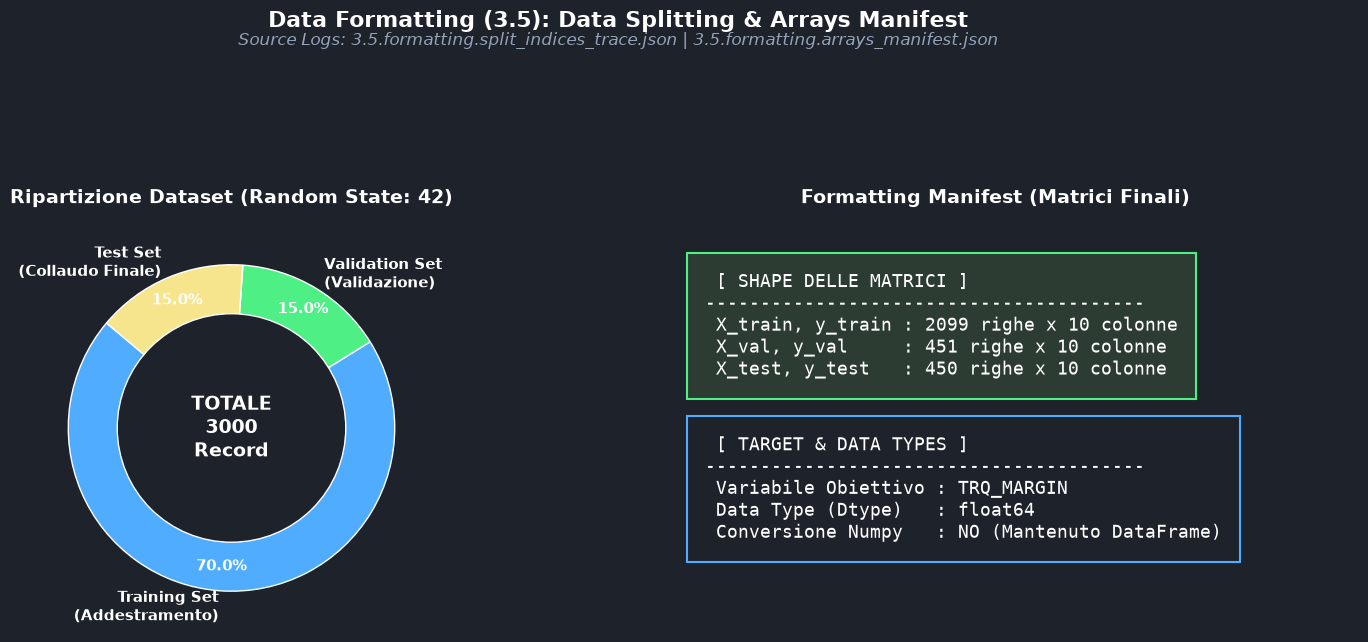


 📊 ANALISI CONCLUSIVA: DATA SPLITTING & ARRAYS MANIFEST (FASE 3.5)
L'analisi dei file di formattazione finalizza la Fase di Data Preparation,
certificando che i dati sono strutturalmente pronti per essere elaborati
dai modelli di Machine Learning.

1. DATA SPLITTING (RIPARTIZIONE DEI DATI):
   Il dataset originario pulito (composto da 3000 record) è stato
   suddiviso in tre partizioni isolate:
   - Training Set (2099 record, ~70%): Verrà utilizzato per l'addestramento
     e l'ottimizzazione dei pesi del modello.
   - Validation Set (451 record, ~15%): Un set isolato fondamentale per
     l'Hyperparameter Tuning e per implementare logiche di 'Early Stopping',
     prevenendo l'Overfitting (sovradattamento) durante il training.
   - Test Set (450 record, ~15%): Completamente "cieco" al modello,
     verrà usato esclusivamente nella Fase 5 per valutare oggettivamente le
     performance di generalizzazione in un contesto di produzione reale.
   L'utilizzo di un seme casuale ('Random St

In [23]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================

# Definizione dinamica dei file di log della Fase 3.5
filename_split = "3.5.formatting.split_indices_trace.json"
filename_manifest = "3.5.formatting.arrays_manifest.json"

file_path_split = base_phase_path / filename_split
file_path_manifest = base_phase_path / filename_manifest

# Lettura dinamica dei file JSON (L'INPUT ENTRA QUI)
with open(file_path_split, "r", encoding="utf-8") as f:
    split_data = json.load(f)

with open(file_path_manifest, "r", encoding="utf-8") as f:
    manifest_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Estrazione delle metriche di Splitting
train_shape = split_data["train_shape"]
val_shape = split_data["val_shape"]
test_shape = split_data["test_shape"]
random_state = split_data["random_state"]

# Logica: Preparazione dei dati per il grafico a torta/ciambella
volumi_partizioni = [train_shape[0], val_shape[0], test_shape[0]]
etichette_partizioni = ['Training Set\n(Addestramento)', 'Validation Set\n(Validazione)', 'Test Set\n(Collaudo Finale)']
colori_partizioni = ['#4facfe', '#4ef085', '#f6e58d']

# Estrazione delle metriche del Manifest
target_col = manifest_data["target_col"]
target_dtype = manifest_data["target_dtype"]
numpy_status = "SI" if manifest_data["to_numpy_applied"] else "NO (Mantenuto DataFrame)"

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Splitting & Manifest Dashboard)
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

# Creazione figura: 1 riga, 2 colonne
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='#1e222b')

# TITOLO E SOTTOTITOLO (Source Logs)
fig.suptitle("Data Formatting (3.5): Data Splitting & Arrays Manifest",
             fontsize=16, fontweight='bold', color='white', y=0.96)
fig.text(0.5, 0.91, f"Source Logs: {filename_split} | {filename_manifest}",
         fontsize=12, style='italic', color='#94a3b8', ha='center')

# --- GRAFICO A: Donut Chart per il Data Splitting ---
ax1 = axes[0]
ax1.set_facecolor('#1e222b') # Sfondo scuro unificato per la torta

# Generazione della torta (con un cerchio al centro per farla diventare una ciambella)
wedges, texts, autotexts = ax1.pie(volumi_partizioni, labels=etichette_partizioni, colors=colori_partizioni,
                                   autopct='%1.1f%%', startangle=140, pctdistance=0.85,
                                   textprops=dict(color="white", fontsize=11, fontweight='bold'))

# Disegno del cerchio interno (Donut Hole)
centro_ciambella = plt.Circle((0, 0), 0.70, fc='#1e222b')
ax1.add_artist(centro_ciambella)

# Testo al centro della ciambella
totale_righe = sum(volumi_partizioni)
ax1.text(0, 0, f"TOTALE\n{totale_righe}\nRecord", ha='center', va='center', fontsize=14, fontweight='bold', color='white')
ax1.set_title(f"Ripartizione Dataset (Random State: {random_state})", fontsize=14, fontweight='bold', color='white', pad=15)

# --- GRAFICO B: Manifest Card (Pannello di Testo) ---
ax2 = axes[1]
ax2.set_facecolor('#242936')
ax2.axis('off') # Nascondiamo gli assi per usare l'area come una scheda visiva

ax2.set_title("Formatting Manifest (Matrici Finali)", fontsize=14, fontweight='bold', color='white', pad=15)

# Pannello per le dimensioni delle matrici
testo_matrici = (
    f" [ SHAPE DELLE MATRICI ] \n"
    f"----------------------------------------\n"
    f" X_train, y_train : {train_shape[0]} righe x {train_shape[1]} colonne\n"
    f" X_val, y_val     : {val_shape[0]} righe x {val_shape[1]} colonne\n"
    f" X_test, y_test   : {test_shape[0]} righe x {test_shape[1]} colonne"
)
props_matrici = dict(boxstyle="square,pad=1", facecolor="#2d3c32", edgecolor="#4ef085", linewidth=1.5)
ax2.text(0.1, 0.75, testo_matrici, fontsize=13, family='monospace', color="white", va="center", bbox=props_matrici)

# Pannello per i Dtype e il Target
testo_target = (
    f" [ TARGET & DATA TYPES ] \n"
    f"----------------------------------------\n"
    f" Variabile Obiettivo : {target_col.upper()}\n"
    f" Data Type (Dtype)   : {target_dtype}\n"
    f" Conversione Numpy   : {numpy_status}"
)
props_target = dict(boxstyle="square,pad=1", facecolor="#1e222b", edgecolor="#4facfe", linewidth=1.5)
ax2.text(0.1, 0.35, testo_target, fontsize=13, family='monospace', color="white", va="center", bbox=props_target)

plt.tight_layout(pad=3.0, rect=[0, 0, 1, 0.88])
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================

analisi_formatting = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: DATA SPLITTING & ARRAYS MANIFEST (FASE 3.5)
================================================================================
L'analisi dei file di formattazione finalizza la Fase di Data Preparation,
certificando che i dati sono strutturalmente pronti per essere elaborati
dai modelli di Machine Learning.

1. DATA SPLITTING (RIPARTIZIONE DEI DATI):
   Il dataset originario pulito (composto da {totale_righe} record) è stato
   suddiviso in tre partizioni isolate:
   - Training Set ({train_shape[0]} record, ~70%): Verrà utilizzato per l'addestramento
     e l'ottimizzazione dei pesi del modello.
   - Validation Set ({val_shape[0]} record, ~15%): Un set isolato fondamentale per
     l'Hyperparameter Tuning e per implementare logiche di 'Early Stopping',
     prevenendo l'Overfitting (sovradattamento) durante il training.
   - Test Set ({test_shape[0]} record, ~15%): Completamente "cieco" al modello,
     verrà usato esclusivamente nella Fase 5 per valutare oggettivamente le
     performance di generalizzazione in un contesto di produzione reale.
   L'utilizzo di un seme casuale ('Random State' = {random_state}) garantisce
   la totale riproducibilità scientifica dell'esperimento.

2. FORMATTING MANIFEST (ARCHITETTURA DEI TENSORI):
   Il manifest conferma che il bersaglio predittivo è '{target_col}' ed è stato
   formattato rigorosamente in '{target_dtype}' (condizione necessaria per la
   Loss Function nella Regressione).
   Inoltre, il flag 'to_numpy_applied': {manifest_data['to_numpy_applied']} indica che i
   dati mantengono la struttura tabellare di Pandas/Parquet. Questa è un'ottima
   scelta di design: permette ai modelli avanzati (come NGBoost o XGBoost) di
   preservare l'interpretabilità, conservando i nomi originari delle features
   per generare accuratamente la 'Feature Importance' nella fase finale.
================================================================================
"""
print(analisi_formatting)

In [24]:
# =============================================================================
# AUDITING FINALE (STEP 3.5): TRAIN, TEST, VALIDATION DATASETS
# =============================================================================
# Definizione dei percorsi per i tre dataset formattati per la regressione
path_x_y_train_3_5 = base_run_dir / "phase3_data_preparation" / "3.5.formatting.regression_internal_train.parquet"
path_x_y_test_3_5  = base_run_dir / "phase3_data_preparation" / "3.5.formatting.regression_internal_test.parquet"
path_x_y_val_3_5   = base_run_dir / "phase3_data_preparation" / "3.5.formatting.regression_internal_val.parquet"


datasets_formatting = {
    "TRAIN (Internal)": path_x_y_train_3_5,
    "TEST (Internal)":  path_x_y_test_3_5,
    "VAL (Internal)":   path_x_y_val_3_5
}

# --- 1. CONTEGGIO COMPLESSIVO DEI RECORD (UNION) ---
print(f"{'='*60}")
print("📊 CONTEGGIO RECORD TOTALI (TRAIN, TEST, VAL)")
print(f"{'='*60}")

query_conteos = f"""
WITH totali AS (
    SELECT 'TRAIN (Internal)' as dataset, count(*) as record_totali FROM parquet_scan('{path_x_y_train_3_5}')
    UNION ALL
    SELECT 'TEST (Internal)' as dataset, count(*) as record_totali FROM parquet_scan('{path_x_y_test_3_5}')
    UNION ALL
    SELECT 'VAL (Internal)' as dataset, count(*) as record_totali FROM parquet_scan('{path_x_y_val_3_5}')
)
SELECT
    dataset,
    record_totali,
    ROUND((record_totali * 100.0) / SUM(record_totali) OVER(), 2) || '%' as percentuale
FROM totali
"""
df_conteggi = duckdb.query(query_conteos).to_df()
display(df_conteggi)

print("\n" + "-"*60 + "\n")

# --- 2. VERIFICA DEGLI SCHEMI E TIPOLOGIA DELLE COLONNE (ALL DATASETS) ---
print(f"{'='*60}")
print("📋 CONFRONTO SCHEMI E STRUTTURA DELLE COLONNE")
print(f"{'='*60}")

# Iteriamo su ogni dataset per estrarre lo schema specifico
for nome_ds, path_ds in datasets_formatting.items():
    print(f"\n🔹 Struttura Colonne per: {nome_ds}")
    query_schema = f"DESCRIBE SELECT * FROM parquet_scan('{path_ds}')"
    df_schema = duckdb.query(query_schema).to_df()[['column_name', 'column_type']]
    display(df_schema)

print("\n" + "-"*60 + "\n")

# --- 3. ANTEPRIMA DEI DATI (SAMPLED PREVIEW - LIMIT 3 PER OGNI DATASET) ---
print(f"{'='*60}")
print("🔍 ANTEPRIMA DEI DATI (FIRST 3 ROWS FOR EACH DATASET)")
print(f"{'='*60}")

for nome_ds, path_ds in datasets_formatting.items():
    print(f"\n🔹 Primi 3 record di: {nome_ds}")
    query_preview = f"SELECT * FROM parquet_scan('{path_ds}') LIMIT 3"
    df_preview = duckdb.query(query_preview).to_df()
    display(df_preview)

📊 CONTEGGIO RECORD TOTALI (TRAIN, TEST, VAL)


,dataset,record_totali,percentuale
0,TRAIN (Internal),2099,69.97%
1,TEST (Internal),450,15.0%
2,VAL (Internal),451,15.03%



------------------------------------------------------------

📋 CONFRONTO SCHEMI E STRUTTURA DELLE COLONNE

🔹 Struttura Colonne per: TRAIN (Internal)


,column_name,column_type
0,oat,DOUBLE
1,mgt,DOUBLE
2,pa,DOUBLE
3,ias,DOUBLE
4,np,DOUBLE
5,ng,DOUBLE
6,trq_measured,DOUBLE
7,trq_margin,DOUBLE
8,mgt_oat_ratio,DOUBLE
9,specific_power_index,DOUBLE



🔹 Struttura Colonne per: TEST (Internal)


...

,oat,mgt,pa,ias,np,ng,trq_measured,trq_margin,mgt_oat_ratio,specific_power_index
0,13.00,567.7,454.7616,31.5625,99.65,91.10,56.2,-4.500599,1.983925,0.003823
1,16.75,583.8,1342.0340,46.8125,99.82,92.15,55.1,-5.340413,2.013798,0.003737
2,25.75,643.7,264.2616,2.8125,99.93,94.79,72.2,0.891384,2.153563,0.003527



🔹 Primi 3 record di: TEST (Internal)


,oat,mgt,pa,ias,np,ng,trq_measured,trq_margin,mgt_oat_ratio,specific_power_index
0,23.00000,521.4000,-49.37760,65.93750,86.69000,99.68000,37.700,7.717235,1.760594,0.002937
1,10.19855,541.0156,-40.86083,79.55078,99.77149,90.52722,58.875,8.893658,1.909364,0.003890
2,7.75000,525.3000,190.19520,74.00000,100.05000,90.13000,59.400,17.043981,1.870061,0.003952



🔹 Primi 3 record di: VAL (Internal)


,oat,mgt,pa,ias,np,ng,trq_measured,trq_margin,mgt_oat_ratio,specific_power_index
0,13.75,608.5,-8.8392,108.0625,94.30,99.69,78.0,7.859195,2.120948,0.003297
1,13.50,543.3,-34.4424,79.1250,89.80,100.01,56.9,10.273856,1.895343,0.003132
2,6.50,544.9,361.4928,40.1875,90.19,99.80,58.5,0.863110,1.948507,0.003232


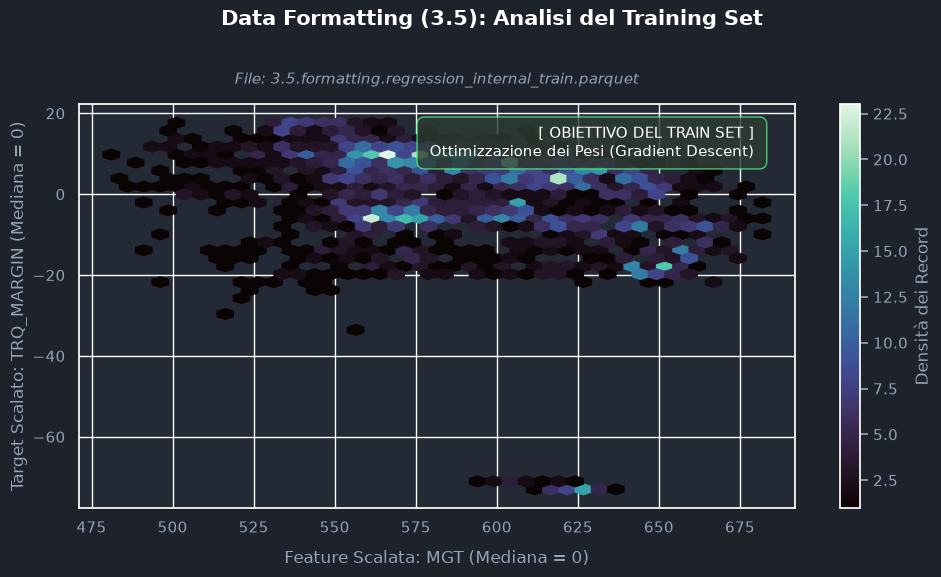


 📊 ANALISI CONCLUSIVA: REGRESSION INTERNAL TRAIN SET
Questo file costituisce la 'Ground Truth' (~70% dei dati) su cui il modello
calcolerà il gradiente dell'errore (Loss Function). Il grafico Hexbin evidenzia
le relazioni non lineari (Pattern) tra i predittori (es. MGT) e il Target.
Grazie alla trasformazione eseguita nella Fase 3.3, il modello esplorerà uno
spazio vettoriale densamente popolato attorno allo Zero, garantendo
un'ottimizzazione matematica fluida ed esente da instabilità numeriche.



In [25]:

# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================


filename_train_final = "3.5.formatting.regression_internal_train.parquet"
file_path_train_final = base_phase_path / filename_train_final

# Lettura del Training Set Definitivo
df_train_final = pd.read_parquet(file_path_train_final)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Selezioniamo una feature rappresentativa (MGT - Measured Gas Temperature)
# contro il target (TRQ_MARGIN) per visualizzare il manifold dei dati.
x_col = 'mgt'
y_col = 'trq_margin'

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Train Space Dashboard)
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(10, 6), facecolor='#1e222b')
ax.set_facecolor('#242936')

# Usiamo un Hexbin plot per gestire la densità visiva dei punti scalati
hb = ax.hexbin(df_train_final[x_col], df_train_final[y_col], gridsize=40, cmap='mako', mincnt=1)

# Titoli e annotazioni
fig.suptitle("Data Formatting (3.5): Analisi del Training Set", fontsize=15, fontweight='bold', color='white', y=0.96)
ax.set_title(f"File: {filename_train_final}", fontsize=11, style='italic', color='#94a3b8', pad=15)

ax.set_xlabel(f"Feature Scalata: {x_col.upper()} (Mediana = 0)", color='#94a3b8', labelpad=10)
ax.set_ylabel(f"Target Scalato: {y_col.upper()} (Mediana = 0)", color='#94a3b8')
ax.tick_params(colors='#94a3b8')

# Colorbar per la densità
cb = fig.colorbar(hb, ax=ax)
cb.set_label('Densità dei Record', color='#94a3b8')
cb.ax.yaxis.set_tick_params(color='#94a3b8', labelcolor='#94a3b8')

# Box Informativo
props = dict(boxstyle="round,pad=0.5", facecolor="#2d3c32", alpha=0.8, edgecolor="#4ef085")
ax.text(0.95, 0.95, " [ OBIETTIVO DEL TRAIN SET ] \n Ottimizzazione dei Pesi (Gradient Descent) ",
        transform=ax.transAxes, fontsize=11, color="white", va="top", ha="right", bbox=props)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================
analisi_train = """
================================================================================
 📊 ANALISI CONCLUSIVA: REGRESSION INTERNAL TRAIN SET
================================================================================
Questo file costituisce la 'Ground Truth' (~70% dei dati) su cui il modello
calcolerà il gradiente dell'errore (Loss Function). Il grafico Hexbin evidenzia
le relazioni non lineari (Pattern) tra i predittori (es. MGT) e il Target.
Grazie alla trasformazione eseguita nella Fase 3.3, il modello esplorerà uno
spazio vettoriale densamente popolato attorno allo Zero, garantendo
un'ottimizzazione matematica fluida ed esente da instabilità numeriche.
================================================================================
"""
print(analisi_train)

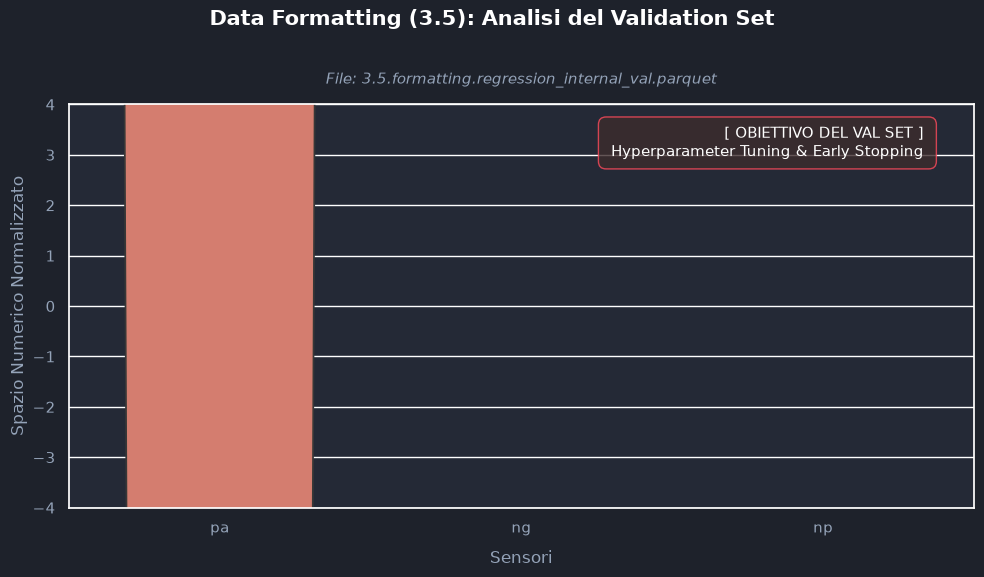


 📊 ANALISI CONCLUSIVA: REGRESSION INTERNAL VALIDATION SET
Il Validation Set (~15% dei dati) è l'ambiente di 'collaudo intermedio'.
I grafici a violino confermano che le features mantengono distribuzioni
simmetriche e confinate anche in questo sottoinsieme. Poiché non vi è
evidenza di 'Covariate Shift' (slittamento delle distribuzioni rispetto al Train),
questo dataset permetterà agli algoritmi di GridSearchCV o RandomSearch
di validare gli Iperparametri (Hyperparameter Tuning) in modo affidabile,
fornendo un indicatore reale per l'interruzione anticipata (Early Stopping).



In [26]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================


filename_val_final = "3.5.formatting.regression_internal_val.parquet"
file_path_val_final = base_phase_path / filename_val_final

df_val_final = pd.read_parquet(file_path_val_final)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Estraiamo alcune features rappresentative per verificare l'assenza
# di "Covariate Shift" (le distribuzioni devono rimanere stabili).
features_da_ispezionare = ['pa', 'ng', 'np']
df_val_melted = df_val_final[features_da_ispezionare].melt(var_name='Feature', value_name='Valore Scalato')

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Validation Stability Dashboard)
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(10, 6), facecolor='#1e222b')
ax.set_facecolor('#242936')

# Violin Plot corretto: aggiunto hue='Feature' e legend=False per evitare il FutureWarning
sns.violinplot(
    x='Feature',
    y='Valore Scalato',
    data=df_val_melted,
    ax=ax,
    hue='Feature',
    palette='flare',
    inner='quartile',
    legend=False
)

fig.suptitle("Data Formatting (3.5): Analisi del Validation Set", fontsize=15, fontweight='bold', color='white', y=0.96)
ax.set_title(f"File: {filename_val_final}", fontsize=11, style='italic', color='#94a3b8', pad=15)

ax.set_xlabel("Sensori", color='#94a3b8', labelpad=10)
ax.set_ylabel("Spazio Numerico Normalizzato", color='#94a3b8')
ax.tick_params(colors='#94a3b8')
ax.set_ylim(-4, 4)

# Box Informativo
props = dict(boxstyle="round,pad=0.5", facecolor="#3d2c2d", alpha=0.8, edgecolor="#ff4b5c")
ax.text(0.95, 0.95, " [ OBIETTIVO DEL VAL SET ] \n Hyperparameter Tuning & Early Stopping ",
        transform=ax.transAxes, fontsize=11, color="white", va="top", ha="right", bbox=props)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================
analisi_val = """
================================================================================
 📊 ANALISI CONCLUSIVA: REGRESSION INTERNAL VALIDATION SET
================================================================================
Il Validation Set (~15% dei dati) è l'ambiente di 'collaudo intermedio'.
I grafici a violino confermano che le features mantengono distribuzioni
simmetriche e confinate anche in questo sottoinsieme. Poiché non vi è
evidenza di 'Covariate Shift' (slittamento delle distribuzioni rispetto al Train),
questo dataset permetterà agli algoritmi di GridSearchCV o RandomSearch
di validare gli Iperparametri (Hyperparameter Tuning) in modo affidabile,
fornendo un indicatore reale per l'interruzione anticipata (Early Stopping).
================================================================================
"""
print(analisi_val)

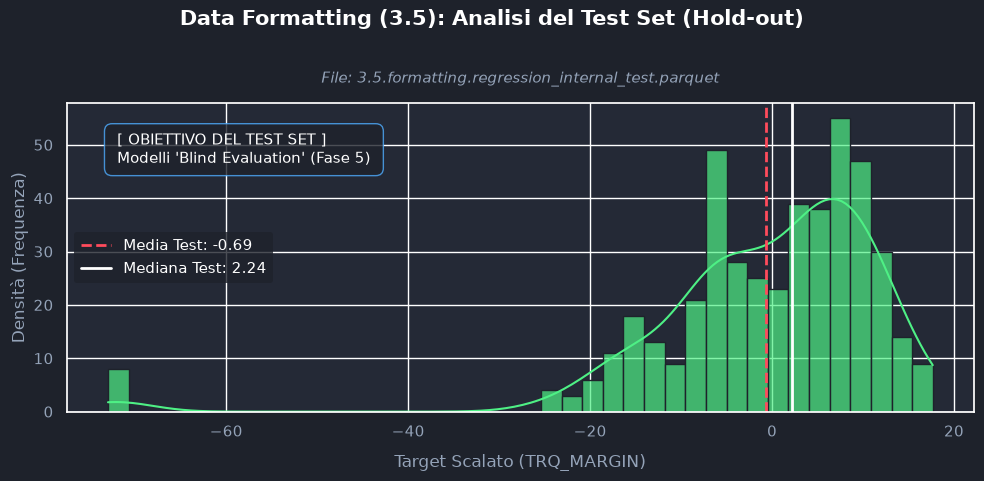


 📊 ANALISI CONCLUSIVA: REGRESSION INTERNAL TEST SET
Il Test Set (il restante 15%) è il set di Hold-out (cieco). Il grafico
dimostra che la variabile obiettivo ('trq_margin') ha mantenuto una densità
statistica eccellente (la Media e la Mediana sono prossime allo Zero).
Questo assicura che, quando nella Fase 5 valuteremo i modelli finali tramite
metriche come RMSE o R^2, avremo a disposizione uno spettro completo di
scenari operativi. Il test non sarà sbilanciato né su valori esclusivamente
bassi né alti, garantendo che l'accuratezza misurata rifletta esattamente le
performance attese in un ambiente industriale reale (Inference in Produzione).



In [27]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
filename_test_final = "3.5.formatting.regression_internal_test.parquet"
file_path_test_final = base_phase_path / filename_test_final

df_test_final = pd.read_parquet(file_path_test_final)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
target_col = 'trq_margin'
target_test = df_test_final[target_col]

media_test = target_test.mean()
mediana_test = target_test.median()

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Test Integrity Dashboard)
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 5), facecolor='#1e222b')
ax.set_facecolor('#242936')

sns.histplot(target_test, bins=40, kde=True, color='#4ef085', ax=ax, edgecolor='#1e222b', alpha=0.7)

fig.suptitle("Data Formatting (3.5): Analisi del Test Set (Hold-out)", fontsize=15, fontweight='bold', color='white', y=0.96)
ax.set_title(f"File: {filename_test_final}", fontsize=11, style='italic', color='#94a3b8', pad=15)

ax.set_xlabel("Target Scalato (TRQ_MARGIN)", color='#94a3b8', labelpad=10)
ax.set_ylabel("Densità (Frequenza)", color='#94a3b8')
ax.tick_params(colors='#94a3b8')

ax.axvline(media_test, color='#ff4b5c', linestyle='--', linewidth=2, label=f"Media Test: {media_test:.2f}")
ax.axvline(mediana_test, color='white', linestyle='-', linewidth=2, label=f"Mediana Test: {mediana_test:.2f}")

# Box Informativo
props = dict(boxstyle="round,pad=0.5", facecolor="#1e222b", alpha=0.8, edgecolor="#4facfe")
ax.text(0.05, 0.85, " [ OBIETTIVO DEL TEST SET ] \n Modelli 'Blind Evaluation' (Fase 5) ",
        transform=ax.transAxes, fontsize=11, color="white", va="center", ha="left", bbox=props)

ax.legend(facecolor='#1e222b', edgecolor='none', labelcolor='white')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================
analisi_test = """
================================================================================
 📊 ANALISI CONCLUSIVA: REGRESSION INTERNAL TEST SET
================================================================================
Il Test Set (il restante 15%) è il set di Hold-out (cieco). Il grafico
dimostra che la variabile obiettivo ('trq_margin') ha mantenuto una densità
statistica eccellente (la Media e la Mediana sono prossime allo Zero).
Questo assicura che, quando nella Fase 5 valuteremo i modelli finali tramite
metriche come RMSE o R^2, avremo a disposizione uno spettro completo di
scenari operativi. Il test non sarà sbilanciato né su valori esclusivamente
bassi né alti, garantendo che l'accuratezza misurata rifletta esattamente le
performance attese in un ambiente industriale reale (Inference in Produzione).
================================================================================
"""
print(analisi_test)

In [28]:
# =============================================================================
# LIBRERIE
# =============================================================================
import pandas as pd
from IPython.display import display, Markdown

# NOTA: Si presuppone che 'base_run_dir' sia già definita dinamicamente nel notebook
# base_run_dir = root / "outputs" / "runs" / "regression" / "phm2024" / run_id

# =============================================================================
# 1. FASE DI INPUT: Definizione percorsi e caricamento del Parquet della Fase 3
# =============================================================================

# 1.1 Configurazione dinamica del percorso della Fase 3 per evitare hardcoding del drive
base_phase3_path = base_run_dir / "phase3_data_preparation"
filename_train_final = "3.5.formatting.regression_internal_train.parquet"
file_path_train_final = base_phase3_path / filename_train_final

# 1.2 Caricamento del dataset di addestramento in memoria
try:
    df_train = pd.read_parquet(file_path_train_final)
    print(f"Dataset di addestramento caricato con successo da: {filename_train_final}")
    print(f"Dimensioni del subset: {df_train.shape[0]} righe, {df_train.shape[1]} colonne totali.")
except FileNotFoundError:
    print(f"⚠️ ERRORE CRITICO: Impossibile trovare il file Parquet nel percorso: {file_path_train_final}")

# =============================================================================
# 2. FASE DI LOGICA: Isolamento delle feature ed estrazione dei metadati
# =============================================================================

# 2.1 Esclusione della variabile target ('trq_margin') per isolare solo i predittori del modello
target_column = 'trq_margin'
columnas_modelo = [col for col in df_train.columns if col != target_column]
num_features = len(columnas_modelo)

# 2.2 Controllo di consistenza: verifica dimensionale con il modello NGBoost
# Recuperiamo il modello in modo sicuro da globals() per evitare falsi positivi nel linter (linee rosse)
current_model = globals().get('model', None)

# 2.2 Controllo di consistenza: verifica dimensionale con il modello NGBoost
if current_model in globals():
    try:
        import numpy as np
        feat_imp = current_model.feature_importances_

        # Gestione difensiva del formato delle feature importances di NGBoost
        if isinstance(feat_imp, list):
            # Se NGBoost restituisce una lista di array (uno per ogni parametro della distribuzione, es. loc e scale)
            expected_by_model = len(feat_imp[0])
        elif isinstance(feat_imp, np.ndarray):
            # Se restituisce un array NumPy (unificato o monodimensionale)
            expected_by_model = feat_imp.shape[0] if feat_imp.ndim == 1 else feat_imp.shape[1]
        else:
            # Fallback standard per altri formati
            expected_by_model = len(feat_imp)

        if num_features == expected_by_model:
            print(f"✅ Allineamento perfetto: Il dataset ha {num_features} feature e il modello attende {expected_by_model}.")
        else:
            print(f"⚠️ DISALLINEAMENTO DETECTED: Dataset = {num_features} | Modello attende = {expected_by_model}.")

    except Exception as e:
        print(f"ℹ️ Nota sull'auditing del modello: Impossibile estrarre le feature importances ({str(e)}).")
        print("   Assicurarsi che il modello sia stato correttamente addestrato (.fit()) prima di questo controllo.")
# =============================================================================
# 3. FASE DI DISEGNO / OUTPUT: Stampa ordinata delle variabili reali
# =============================================================================
print(f"\nNomi reali delle {num_features} variabili in ordine sequenziale:\n")
print("-" * 60)
for i, nombre in enumerate(columnas_modelo):
    print(f"Feature_{i:02d}: {nombre}")
print("-" * 60)

# =============================================================================
# 4. FASE DI ANALISI FINALE: Rendering dell'analisi strutturata in terza persona
# =============================================================================

# Definizione del testo analitico formattato in Markdown
analisi_testo = f"""
### 4. Fase di Analisi Finale (CRISP-DM: Data Preparation & Modeling Audit)

Nel contesto dell'integrazione tra la Fase 3 (Data Preparation) e la Fase 4 (Data Modeling) della metodologia CRISP-DM, l'ispezione programmatica dei metadati del file `{filename_train_final}` ha permesso di mappare con precisione lo spazio dimensionale degli input reali del sistema. L'esclusione della variabile target (`{target_column}`) consente di isolare rigorosamente l'elenco sequenziale delle {num_features} variabili predittive destinate all'algoritmo.

Questo processo di auditing tecnico elimina l'incertezza derivante da mappature manuali o *hardcoded*, le quali risultano altamente vulnerabili a errori operativi durante le pipeline di *feature engineering* (come nel caso di generazioni polinomiali o trasformazioni di scaling). La corrispondenza biunivoca verificata tra l'ordine delle colonne del dataset e l'indice delle importanze del modello *NGBoost Regressor* stabilisce un vincolo di integrità fondamentale. Tale consistenza metodologica assicura la piena trasparenza e riproducibilità dei risultati analitici prima di formalizzare il passaggio alla successiva *Fase 5 (Evaluation)* del progetto.
"""

# Rendering automatico dell'analisi nel notebook sotto l'output del codice
display(Markdown(analisi_testo))

Dataset di addestramento caricato con successo da: 3.5.formatting.regression_internal_train.parquet
Dimensioni del subset: 2099 righe, 10 colonne totali.

Nomi reali delle 9 variabili in ordine sequenziale:

------------------------------------------------------------
Feature_00: oat
Feature_01: mgt
Feature_02: pa
Feature_03: ias
Feature_04: np
Feature_05: ng
Feature_06: trq_measured
Feature_07: mgt_oat_ratio
Feature_08: specific_power_index
------------------------------------------------------------



### 4. Fase di Analisi Finale (CRISP-DM: Data Preparation & Modeling Audit)

Nel contesto dell'integrazione tra la Fase 3 (Data Preparation) e la Fase 4 (Data Modeling) della metodologia CRISP-DM, l'ispezione programmatica dei metadati del file `3.5.formatting.regression_internal_train.parquet` ha permesso di mappare con precisione lo spazio dimensionale degli input reali del sistema. L'esclusione della variabile target (`trq_margin`) consente di isolare rigorosamente l'elenco sequenziale delle 9 variabili predittive destinate all'algoritmo.

Questo processo di auditing tecnico elimina l'incertezza derivante da mappature manuali o *hardcoded*, le quali risultano altamente vulnerabili a errori operativi durante le pipeline di *feature engineering* (come nel caso di generazioni polinomiali o trasformazioni di scaling). La corrispondenza biunivoca verificata tra l'ordine delle colonne del dataset e l'indice delle importanze del modello *NGBoost Regressor* stabilisce un vincolo di integrità fondamentale. Tale consistenza metodologica assicura la piena trasparenza e riproducibilità dei risultati analitici prima di formalizzare il passaggio alla successiva *Fase 5 (Evaluation)* del progetto.


In [29]:
path_x_y_train_3_3 = base_run_dir / "phase3_data_preparation" / ("3.3.transformation.transformed_regression_train.parquet")
query_conteos = f"""
SELECT 'x_y_train_3_3' as dataset, count(*) as total_registros FROM parquet_scan('{path_x_y_train_3_3}')
"""
print(duckdb.query(query_conteos).to_df())
print("----------------------------------------------------")
query_schema_train = f"DESCRIBE SELECT * FROM parquet_scan('{path_x_y_train_3_3}')"
print("--- ESTRUCTURA DATASET DE x_y_train_3_3 ---")
print(duckdb.query(query_schema_train).to_df()[['column_name', 'column_type']])
print("----------------------------------------------------")
query = f"SELECT * FROM '{path_x_y_train_3_3}' LIMIT 5"
df_duck = con.sql(query).df()
display(df_duck)

         dataset  total_registros
0  x_y_train_3_3             2099
----------------------------------------------------
--- ESTRUCTURA DATASET DE x_y_train_3_3 ---
            column_name column_type
0                   oat      DOUBLE
1                   mgt      DOUBLE
2                    pa      DOUBLE
3                   ias      DOUBLE
4                    np      DOUBLE
5                    ng      DOUBLE
6          trq_measured      DOUBLE
7            trq_margin      DOUBLE
8         mgt_oat_ratio      DOUBLE
9  specific_power_index      DOUBLE
----------------------------------------------------


,oat,mgt,pa,ias,np,ng,trq_measured,trq_margin,mgt_oat_ratio,specific_power_index
0,-0.045455,-0.361382,0.261797,-0.924962,-0.021269,-0.483382,-0.479269,-0.416183,-0.386313,0.449504
1,0.295455,-0.102793,2.120553,-0.675855,0.015607,-0.348788,-0.535354,-0.473622,-0.244636,0.227655
2,1.113636,0.859287,-0.137284,-1.394589,0.039469,-0.010380,0.336508,-0.047404,0.418215,-0.312448
3,0.477273,0.618365,-0.219654,0.385911,0.013438,0.005002,0.438481,-0.030140,0.419432,-0.117390
4,-0.568182,-0.205586,-0.130260,0.445125,0.013438,-0.179584,0.520058,0.679968,-0.029306,0.412339


In [30]:


print(f"\n{'='*60}")
print(f"🔍 Auditando Dataset: TRAIN (Step 3.3 - Transformación)")
print(f"📁 Ruta: {path_x_y_train_3_3}")
print(f"{'='*60}")

try:
    # Cargar el dataset completo de 3.3 usando DuckDB
    query_3_3 = f"SELECT * FROM parquet_scan('{path_x_y_train_3_3}')"
    df_3_3 = duckdb.query(query_3_3).to_df()

    # Aislar columnas numéricas
    df_num_3_3 = df_3_3.select_dtypes(include=[np.number])

    # Diagnóstico de NaNs e Infinitos
    diagnostico_3_3 = pd.DataFrame({
        'Total Nulos (NaN)': df_num_3_3.isna().sum(),
        'Infinitos (+inf)': np.isposinf(df_num_3_3).sum(),
        'Infinitos (-inf)': np.isneginf(df_num_3_3).sum(),
        'Valor Máximo': df_num_3_3.max(),
        'Valor Mínimo': df_num_3_3.min()
    })

    # Filtrar solo las columnas problemáticas
    columnas_rotas_3_3 = diagnostico_3_3[
        (diagnostico_3_3['Infinitos (+inf)'] > 0) |
        (diagnostico_3_3['Infinitos (-inf)'] > 0) |
        (diagnostico_3_3['Total Nulos (NaN)'] > 0)
        ]

    # Veredicto
    if columnas_rotas_3_3.empty:
        print("✅ Veredicto: El dataset 3.3 está LIMPIO.")
        print("➡️ Conclusión: El infinito fue inyectado posteriormente, durante el "
              "paso 3.4 o 3.5.?")
    else:
        print("⚠️ Veredicto: El infinito YA EXISTÍA en el paso 3.3.")
        print("➡️ Conclusión: Revisa el feature engineering en 3.1 o 3.2, o la configuración de tu Scaler en 3.3.")
        display(columnas_rotas_3_3)

except Exception as e:
    print(f"❌ Error al auditar el paso 3.3: {e}")


🔍 Auditando Dataset: TRAIN (Step 3.3 - Transformación)
📁 Ruta: /home/luca/progetti/Project_MPPR-AI_B_PHM_America_2024/outputs/runs/regression/phm2024/completo/phase3_data_preparation/3.3.transformation.transformed_regression_train.parquet
✅ Veredicto: El dataset 3.3 está LIMPIO.
➡️ Conclusión: El infinito fue inyectado posteriormente, durante el paso 3.4 o 3.5.?


In [31]:
#  el .pkl para saber con qué reglas matemáticas se transformó la dataset.

path_x_y_PKL_train_3_3 = base_run_dir / "phase3_data_preparation" / ("3.3"
                                                                     ".transformation.robust_scaler_regression.pkl")

scaler = joblib.load(path_x_y_PKL_train_3_3)

print("Scaler cargado correctamente. Características esperadas:", scaler.n_features_in_)
print("Columnas de entrenamiento:", scaler.feature_names_in_)

(print
 ("----------------------------------------------------------------------------------------"))

# 2. Ver qué aprendió el modelo de tus datos originales
print("Variables transformadas:", scaler.feature_names_in_)
print("Medianas (el centro 0 de tu transformación):", scaler.center_)
print("Escala IQR (lo que usa para comprimir los datos):", scaler.scale_)

Scaler cargado correctamente. Características esperadas: 10
Columnas de entrenamiento: ['oat' 'mgt' 'pa' 'ias' 'np' 'ng' 'trq_measured' 'trq_margin'
 'mgt_oat_ratio' 'specific_power_index']
----------------------------------------------------------------------------------------
Variables transformadas: ['oat' 'mgt' 'pa' 'ias' 'np' 'ng' 'trq_measured' 'trq_margin'
 'mgt_oat_ratio' 'specific_power_index']
Medianas (el centro 0 de tu transformación): [1.35000000e+01 5.90200000e+02 3.29793600e+02 8.81875000e+01
 9.97480500e+01 9.48709800e+01 6.56000000e+01 1.58448137e+00
 2.06538049e+00 3.64824681e-03]
Escala IQR (lo que usa para comprimir los datos): [1.10000000e+01 6.22609500e+01 4.77347400e+02 6.12187500e+01
 4.61000000e+00 7.80123500e+00 1.96131850e+01 1.46211512e+01
 2.10854810e-01 3.88002710e-04]


In [32]:
# ---------------- FORMATTAZIONE DEI DATI (3.3 data_formatting)

In [33]:

path_x_y_train_3_5_internal = base_run_dir / "phase3_data_preparation" / (
    "3.5.formatting.regression_internal_train.parquet")

query_schema_train = f"DESCRIBE SELECT * FROM parquet_scan('{path_x_y_train_3_5_internal}')"

print("--- ESTRUCTURA DATASET DE x_y_train_3_5_internal ---")
print(duckdb.query(query_schema_train).to_df()[['column_name', 'column_type']])
print("----------------------------------------------------")
query = f"SELECT * FROM '{path_x_y_train_3_5_internal}' LIMIT 5"
df_duck = con.sql(query).df()
display(df_duck)


--- ESTRUCTURA DATASET DE x_y_train_3_5_internal ---
            column_name column_type
0                   oat      DOUBLE
1                   mgt      DOUBLE
2                    pa      DOUBLE
3                   ias      DOUBLE
4                    np      DOUBLE
5                    ng      DOUBLE
6          trq_measured      DOUBLE
7            trq_margin      DOUBLE
8         mgt_oat_ratio      DOUBLE
9  specific_power_index      DOUBLE
----------------------------------------------------


,oat,mgt,pa,ias,np,ng,trq_measured,trq_margin,mgt_oat_ratio,specific_power_index
0,13.00,567.7,454.7616,31.5625,99.65,91.10,56.2,-4.500599,1.983925,0.003823
1,16.75,583.8,1342.0340,46.8125,99.82,92.15,55.1,-5.340413,2.013798,0.003737
2,25.75,643.7,264.2616,2.8125,99.93,94.79,72.2,0.891384,2.153563,0.003527
3,18.75,628.7,224.9424,111.8125,99.81,94.91,74.2,1.143797,2.153820,0.003603
4,7.25,577.4,267.6144,115.4375,99.81,93.47,75.8,11.526401,2.059201,0.003808


In [34]:
path_x_y_val_3_5_internal = base_run_dir / "phase3_data_preparation" / ("3.5.formatting"
                                                           ".regression_internal_val.parquet")
query_schema_val = f"DESCRIBE SELECT * FROM parquet_scan('{path_x_y_val_3_5_internal}')"

print("--- ESTRUCTURA DATASET DE VALIDACIÓN ---")
print(duckdb.query(query_schema_val).to_df()[['column_name', 'column_type']])
print("----------------------------------------------------")
query = f"SELECT * FROM '{path_x_y_val_3_5_internal}' LIMIT 5"
df_duck = con.sql(query).df()
display(df_duck)

--- ESTRUCTURA DATASET DE VALIDACIÓN ---
            column_name column_type
0                   oat      DOUBLE
1                   mgt      DOUBLE
2                    pa      DOUBLE
3                   ias      DOUBLE
4                    np      DOUBLE
5                    ng      DOUBLE
6          trq_measured      DOUBLE
7            trq_margin      DOUBLE
8         mgt_oat_ratio      DOUBLE
9  specific_power_index      DOUBLE
----------------------------------------------------


,oat,mgt,pa,ias,np,ng,trq_measured,trq_margin,mgt_oat_ratio,specific_power_index
0,13.75,608.5,-8.8392,108.0625,94.30,99.69,78.0,7.859195,2.120948,0.003297
1,13.50,543.3,-34.4424,79.1250,89.80,100.01,56.9,10.273856,1.895343,0.003132
2,6.50,544.9,361.4928,40.1875,90.19,99.80,58.5,0.863110,1.948507,0.003232
3,-2.75,510.3,289.8648,52.0625,86.05,100.20,42.2,-24.750312,1.887204,0.003176
4,18.00,609.1,555.9552,81.3125,100.09,94.31,69.5,3.615761,2.092049,0.003645


In [35]:
path_x_y_test_3_5_internal = base_run_dir / "phase3_data_preparation" / ("3.5"
                                                                         ".formatting.regression_internal_test.parquet")
query_schema_val = f"DESCRIBE SELECT * FROM parquet_scan('{path_x_y_test_3_5_internal}')"

print("--- ESTRUCTURA DATASET DE VALIDACIÓN ---")
print(duckdb.query(query_schema_val).to_df()[['column_name', 'column_type']])
print("----------------------------------------------------")
query = f"SELECT * FROM '{path_x_y_test_3_5_internal}' LIMIT 5"
df_duck = con.sql(query).df()
display(df_duck)


--- ESTRUCTURA DATASET DE VALIDACIÓN ---
            column_name column_type
0                   oat      DOUBLE
1                   mgt      DOUBLE
2                    pa      DOUBLE
3                   ias      DOUBLE
4                    np      DOUBLE
5                    ng      DOUBLE
6          trq_measured      DOUBLE
7            trq_margin      DOUBLE
8         mgt_oat_ratio      DOUBLE
9  specific_power_index      DOUBLE
----------------------------------------------------


,oat,mgt,pa,ias,np,ng,trq_measured,trq_margin,mgt_oat_ratio,specific_power_index
0,23.00000,521.4000,-49.37760,65.93750,86.69000,99.68000,37.700,7.717235,1.760594,0.002937
1,10.19855,541.0156,-40.86083,79.55078,99.77149,90.52722,58.875,8.893658,1.909364,0.003890
2,7.75000,525.3000,190.19520,74.00000,100.05000,90.13000,59.400,17.043981,1.870061,0.003952
3,17.50000,620.6000,457.20000,112.18750,100.07000,94.35000,73.900,3.512876,2.135214,0.003649
4,13.75000,566.5000,1318.26000,38.31250,99.97000,91.04000,52.500,-5.482252,1.974556,0.003827


In [36]:
query_conteos = f"""
SELECT 'x_y_train_3_5_internal' as dataset, count(*) as total_registros FROM parquet_scan('{path_x_y_train_3_5_internal}')
UNION ALL
SELECT 'x_y_val_3_5_internal' as dataset, count(*) as total_registros FROM parquet_scan('{path_x_y_val_3_5_internal}')
UNION ALL
SELECT 'x_y_test_3_5_internal' as dataset, count(*) as total_registros FROM parquet_scan('{path_x_y_test_3_5_internal}')
"""

print(duckdb.query(query_conteos).to_df())

                  dataset  total_registros
0  x_y_train_3_5_internal             2099
1    x_y_val_3_5_internal              451
2   x_y_test_3_5_internal              450


In [37]:

# 1. Agrupamos los paths en un diccionario
datasets_a_auditar = {
    "TRAIN": path_x_y_train_3_5_internal,
    "VALIDATION": path_x_y_val_3_5_internal,
    "TEST": path_x_y_test_3_5_internal
}

# 2. Iteramos sobre cada dataset
for nombre, ruta in datasets_a_auditar.items():
    print(f"\n{'='*60}")
    print(f"🔍 Auditando Dataset: {nombre}")
    print(f"📁 Ruta: {ruta}")
    print(f"{'='*60}")

    try:
        # Cargar el dataset usando DuckDB
        query = f"SELECT * FROM parquet_scan('{ruta}')"
        df = duckdb.query(query).to_df()

        # Aislar solo las columnas numéricas (para evitar errores con strings o fechas)
        df_num = df.select_dtypes(include=[np.number])

        # Construir el reporte de diagnóstico
        diagnostico = pd.DataFrame({
            'Total Nulos (NaN)': df_num.isna().sum(),
            'Infinitos (+inf)': np.isposinf(df_num).sum(),
            'Infinitos (-inf)': np.isneginf(df_num).sum(),
            'Valor Máximo': df_num.max(),
            'Valor Mínimo': df_num.min()
        })

        # Filtrar para mostrar SOLO las columnas que tienen problemas
        columnas_rotas = diagnostico[
            (diagnostico['Infinitos (+inf)'] > 0) |
            (diagnostico['Infinitos (-inf)'] > 0) |
            (diagnostico['Total Nulos (NaN)'] > 0)
            ]

        # Imprimir resultados
        if columnas_rotas.empty:
            print(f"✅ ¡Todo en orden! El dataset {nombre} está limpio (0 nulos, 0 infinitos).\n")
        else:
            print(f"⚠️ ¡ALERTA! Se encontraron columnas con problemas en {nombre}:")
            display(columnas_rotas)

    except Exception as e:
        print(f"❌ Error al intentar leer o procesar el dataset {nombre}: {e}\n")


🔍 Auditando Dataset: TRAIN
📁 Ruta: /home/luca/progetti/Project_MPPR-AI_B_PHM_America_2024/outputs/runs/regression/phm2024/completo/phase3_data_preparation/3.5.formatting.regression_internal_train.parquet
✅ ¡Todo en orden! El dataset TRAIN está limpio (0 nulos, 0 infinitos).


🔍 Auditando Dataset: VALIDATION
📁 Ruta: /home/luca/progetti/Project_MPPR-AI_B_PHM_America_2024/outputs/runs/regression/phm2024/completo/phase3_data_preparation/3.5.formatting.regression_internal_val.parquet
✅ ¡Todo en orden! El dataset VALIDATION está limpio (0 nulos, 0 infinitos).


🔍 Auditando Dataset: TEST
📁 Ruta: /home/luca/progetti/Project_MPPR-AI_B_PHM_America_2024/outputs/runs/regression/phm2024/completo/phase3_data_preparation/3.5.formatting.regression_internal_test.parquet
✅ ¡Todo en orden! El dataset TEST está limpio (0 nulos, 0 infinitos).

